## **1. Import Required Libraries & Dependencies**

In [ ]:
!pip install -r requirements.txt

## **2. Dataset Acquisition & Storage Connection**

In [ ]:
print("Downloading benchmark wafer map dataset from Google Drive...")

file_id = '1eZ8w6N9hDk6iX3N_m3OQ3y1r4T5u7v8w'
output = 'data/LSWMD.pkl' if os.path.isdir('data') else ('wafer-map-defect-mining/data/LSWMD.pkl' if os.path.isdir('wafer-map-defect-mining/data') else 'LSWMD.pkl')

candidates = ['data/LSWMD.pkl', 'wafer-map-defect-mining/data/LSWMD.pkl', '../data/LSWMD.pkl', 'LSWMD.pkl']
existing = next((c for c in candidates if os.path.exists(c)), None)

if not existing:
    gdown.download(f'https://drive.google.com/uc?id={file_id}', output, quiet=False)
    print("Download complete. File verified.")
else:
    print(f"Dataset already exists locally: {existing}")


In [1]:
import os
import sys
import glob
import ctypes
import tensorflow


# 1. Load CUDA/cuDNN runtime libraries directly from site-packages into process memory
for lib_dir in glob.glob(os.path.join(sys.prefix, "lib", "python*", "site-packages", "nvidia", "*", "lib")):
    for so in glob.glob(os.path.join(lib_dir, "*.so*")):
        try:
            ctypes.CDLL(so, mode=ctypes.RTLD_GLOBAL)
        except Exception:
            pass

# 2. Verify GPU availability with TensorFlow
import tensorflow as tf
gpus = tf.config.list_physical_devices("GPU")
print("Available GPUs:", gpus)


I0000 00:00:1789312330.712136  181882 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789312330.743069  181882 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789312331.641070  181882 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from IPython.display import display
import cv2
import gdown
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import confusion_matrix, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.decomposition import PCA
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.ensemble import IsolationForest
from pyclustering.cluster.cure import cure
from pyclustering.utils import draw_clusters
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score


## **3. Exploratory Data Analysis & Overview**

In [3]:
print("Loading dataset from pickle file, this may take a few minutes due to file size (>2GB)...")

candidates = ['data/LSWMD.pkl', 'wafer-map-defect-mining/data/LSWMD.pkl', '../data/LSWMD.pkl', 'LSWMD.pkl']
data_path = next((c for c in candidates if os.path.exists(c)), None)

if data_path:
    print(f"Reading from {data_path}...")
    df = pd.read_pickle(data_path)
else:
    raise FileNotFoundError(f"Dataset file not found in candidate paths: {candidates}. Please download or place LSWMD.pkl into project directory.")

print(f"Total wafers loaded: {len(df):,}")
print("\n--- Summary Info of Wafer Dataset ---")
df.info()

print("\n--- First 5 Records ---")
display(df.head())


Loading dataset from pickle file, this may take a few minutes due to file size (>2GB)...
Reading from data/LSWMD.pkl...
Total wafers loaded: 811,457

--- Summary Info of Wafer Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811457 entries, 0 to 811456
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   waferMap        811457 non-null  object 
 1   dieSize         811457 non-null  float64
 2   lotName         811457 non-null  object 
 3   waferIndex      811457 non-null  float64
 4   trianTestLabel  811457 non-null  object 
 5   failureType     811457 non-null  object 
dtypes: float64(2), object(4)
memory usage: 37.1+ MB

--- First 5 Records ---


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


In [4]:
# 1. Safely extract text label from 2D array representation
def extract_label(val):
    if isinstance(val, np.ndarray) and val.size > 0:
        return val[0][0]
    return np.nan

df['failureType'] = df['failureType'].apply(extract_label)

# 2. Split into labeled and unlabeled subsets
df_labeled = df[df['failureType'].notna()].copy()

# Standardize 'none' to 'Normal' (defect-free wafers)
df_labeled['failureType'] = df_labeled['failureType'].replace('none', 'Normal')

print(f"Total labeled wafers: {len(df_labeled):,}")
print(f"Total unlabeled wafers: {len(df[df['failureType'].isna()]):,}")

print("\n--- Distribution of 9 Ground Truth Defect Classes ---")
display(df_labeled['failureType'].value_counts().to_frame(name='Count'))


Total labeled wafers: 172,950
Total unlabeled wafers: 638,507

--- Distribution of 9 Ground Truth Defect Classes ---


,Count
failureType,
Normal,147431
Edge-Ring,9680
Edge-Loc,5189
Center,4294
Loc,3593
Scratch,1193
Random,866
Donut,555
Near-full,149


In [5]:
# =====================================================================
# STRATIFIED TRAIN/TEST SPLIT & TRAINING SET BALANCING (PRESERVING REAL TEST DISTRIBUTION)
# =====================================================================
# Ensure 'none' is mapped to 'Normal' if not already done
if 'none' in df_labeled['failureType'].values:
    df_labeled['failureType'] = df_labeled['failureType'].replace('none', 'Normal')

# 1. Independent Stratified Split on original labeled data (Preserves ~85.2% Normal in Test)
df_train_raw, df_test_raw = train_test_split(
    df_labeled, test_size=0.2, random_state=42, stratify=df_labeled['failureType']
)

# 2. Perform Undersampling ONLY on the Training set (1:1 Normal-to-Defect ratio)
df_train_normal = df_train_raw[df_train_raw['failureType'] == 'Normal']
df_train_defect = df_train_raw[df_train_raw['failureType'] != 'Normal']

df_train_normal_sampled = df_train_normal.sample(n=len(df_train_defect), random_state=42)
df_subset = pd.concat([df_train_normal_sampled, df_train_defect]).reset_index(drop=True)

# 3. Prepare realistic test set (Stratified sample up to 10,000 for efficiency or retain full)
if len(df_test_raw) > 10000:
    df_test_real = train_test_split(
        df_test_raw, train_size=10000, random_state=42, stratify=df_test_raw['failureType']
    )[0].reset_index(drop=True)
else:
    df_test_real = df_test_raw.reset_index(drop=True)

# 4. Extract wafer dimensions
df_subset['waferMapDim'] = df_subset['waferMap'].apply(lambda x: x.shape)
df_test_real['waferMapDim'] = df_test_real['waferMap'].apply(lambda x: x.shape)

# === PRINT SUMMARY STATISTICS ===
print(f" Balanced Training Subset created successfully! Total samples: {len(df_subset):,} (Normal: 50.0%)")
normal_test_pct = (df_test_real['failureType'] == 'Normal').mean() * 100
print(f" Independent Real-World Test Set separated! Total samples: {len(df_test_real):,} (Normal: {normal_test_pct:.1f}%)")

print("\n--- CLASS DISTRIBUTION IN BALANCED TRAINING SET ---")
display(df_subset['failureType'].value_counts().to_frame(name='Training Count'))

print("\n--- CLASS DISTRIBUTION IN REALISTIC TEST SET ---")
display(df_test_real['failureType'].value_counts().to_frame(name='Test Count'))


 Balanced Training Subset created successfully! Total samples: 40,830 (Normal: 50.0%)
 Independent Real-World Test Set separated! Total samples: 10,000 (Normal: 85.2%)

--- CLASS DISTRIBUTION IN BALANCED TRAINING SET ---


,Training Count
failureType,
Normal,20415
Edge-Ring,7744
Edge-Loc,4151
Center,3435
Loc,2875
Scratch,954
Random,693
Donut,444
Near-full,119



--- CLASS DISTRIBUTION IN REALISTIC TEST SET ---


,Test Count
failureType,
Normal,8524
Edge-Ring,560
Edge-Loc,300
Center,248
Loc,208
Scratch,69
Random,50
Donut,32
Near-full,9


### **Balanced Training Subset (1:1 Ratio) & Realistic Test Set**

In [6]:
# Standardize image resolution to 64x64
TARGET_SIZE = (64, 64)

def resize_wafer_map(wm):
    wm_uint8 = wm.astype(np.uint8)
    # Use cv2.INTER_NEAREST to preserve discrete values (0: background, 1: die, 2: defect)
    return cv2.resize(wm_uint8, dsize=TARGET_SIZE, interpolation=cv2.INTER_NEAREST)

print("Standardizing wafer map dimensions to 64x64...")
df_subset['waferMap_resized'] = df_subset['waferMap'].apply(resize_wafer_map)
df_test_real['waferMap_resized'] = df_test_real['waferMap'].apply(resize_wafer_map)

print(f"Sample 1 resized shape: {df_subset['waferMap_resized'].iloc[0].shape}")
print(f"Unique pixel values preserved (must be [0, 1, 2]): {np.unique(df_subset['waferMap_resized'].iloc[0])}")
print(f"Balanced Train shape: {len(df_subset):,}, Realistic Test shape: {len(df_test_real):,}")


Standardizing wafer map dimensions to 64x64...
Sample 1 resized shape: (64, 64)
Unique pixel values preserved (must be [0, 1, 2]): [0 1 2]
Balanced Train shape: 40,830, Realistic Test shape: 10,000


### **Large Unlabeled Subset Extraction (100,000 Wafers)**

In [7]:
# 1. Extract unlabeled wafers (where failureType is NaN)
df_unlabeled = df[df['failureType'].isna()].copy()
print(f"Total unlabeled wafers in raw dataset: {len(df_unlabeled):,}")

# 2. Randomly sample 100,000 wafers for large-scale mining
df_unlabeled_subset = df_unlabeled.sample(n=100000, random_state=42).copy()
print(f"Extracted {len(df_unlabeled_subset):,} unlabeled wafers for processing.")

# 3. Resize all to 64x64 using pre-defined resize_wafer_map function
print("Resizing 100,000 unlabeled wafers to 64x64...")
df_unlabeled_subset['waferMap_resized'] = df_unlabeled_subset['waferMap'].apply(resize_wafer_map)

# 4. Retain essential columns and initialize failureType
columns_to_keep = ['waferMap', 'waferMap_resized', 'dieSize', 'lotName', 'waferIndex']
df_final_large = df_unlabeled_subset[columns_to_keep].copy()
df_final_large['failureType'] = np.nan
print(f"Prepared 100k unlabeled mining set: {len(df_final_large):,} samples.")


Total unlabeled wafers in raw dataset: 638,507
Extracted 100,000 unlabeled wafers for processing.
Resizing 100,000 unlabeled wafers to 64x64...
Prepared 100k unlabeled mining set: 100,000 samples.


### **Class Distribution Analysis: Before vs. After Resampling (Plot P1)**

Visualizing class imbalance before and after resampling...


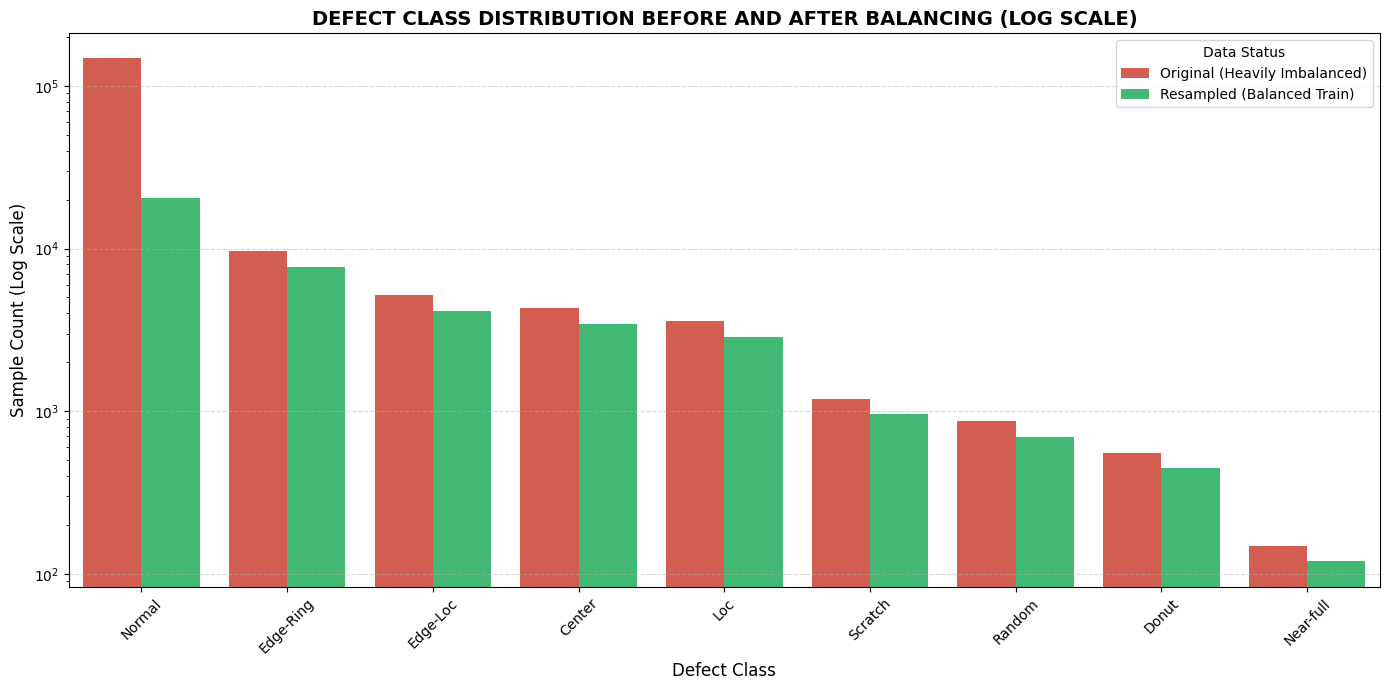

In [8]:
print("Visualizing class imbalance before and after resampling...")
before_balance = df_labeled['failureType'].value_counts().reset_index()
before_balance.columns = ['Defect Class', 'Count']
before_balance['Stage'] = 'Original (Heavily Imbalanced)'

after_balance = df_subset['failureType'].value_counts().reset_index()
after_balance.columns = ['Defect Class', 'Count']
after_balance['Stage'] = 'Resampled (Balanced Train)'

df_viz_balance = pd.concat([before_balance, after_balance])

plt.figure(figsize=(14, 7))
sns.barplot(data=df_viz_balance, x='Defect Class', y='Count', hue='Stage', palette=['#e74c3c', '#2ecc71'])
plt.yscale('log')
plt.title('DEFECT CLASS DISTRIBUTION BEFORE AND AFTER BALANCING (LOG SCALE)', fontsize=14, fontweight='bold')
plt.xlabel('Defect Class', fontsize=12)
plt.ylabel('Sample Count (Log Scale)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Data Status')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### **Wafer Map Visual Inspection across Subsets**

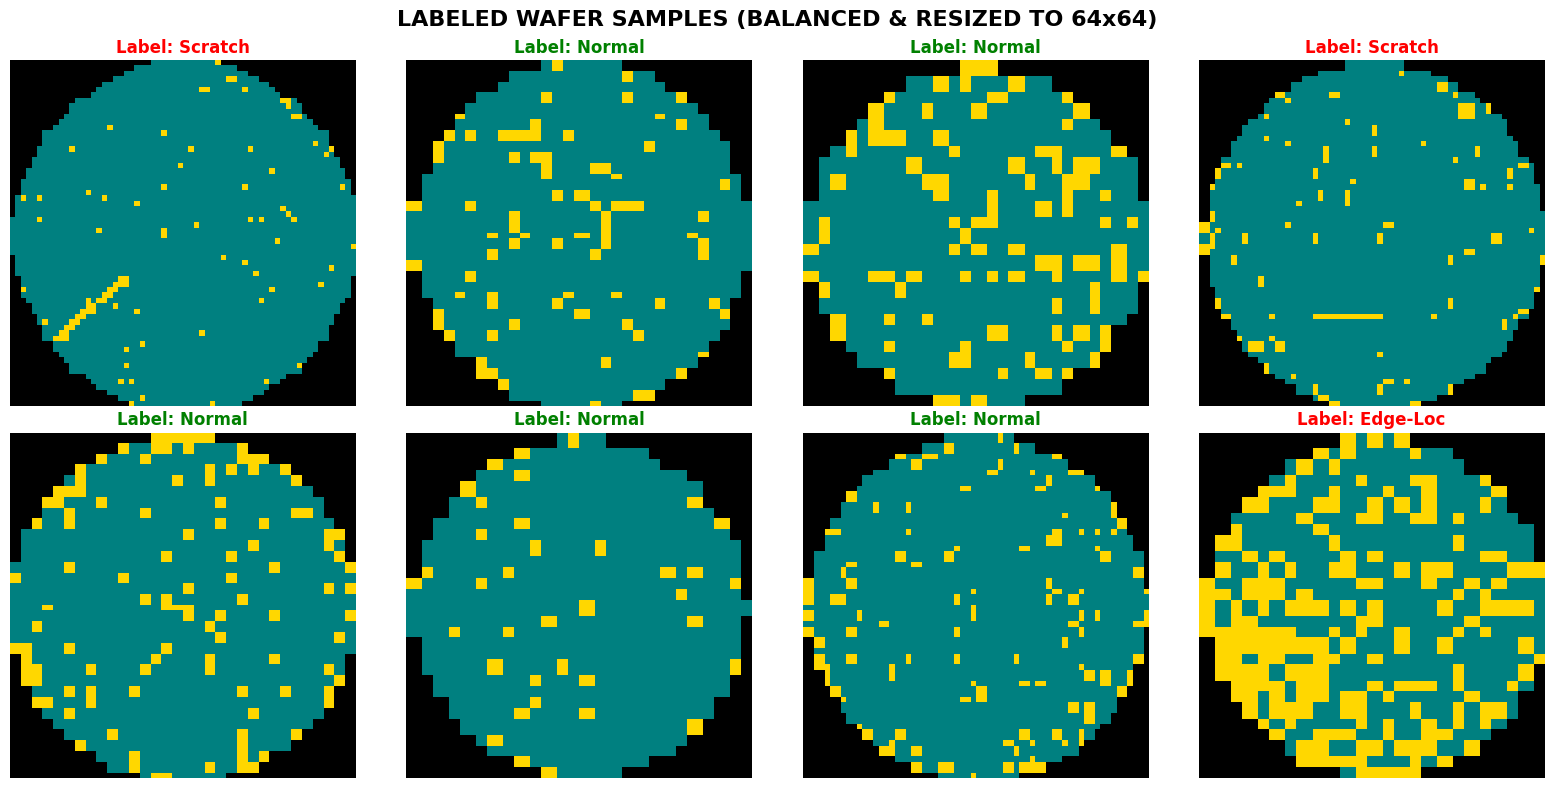


--------------------------------------------------------------------------------



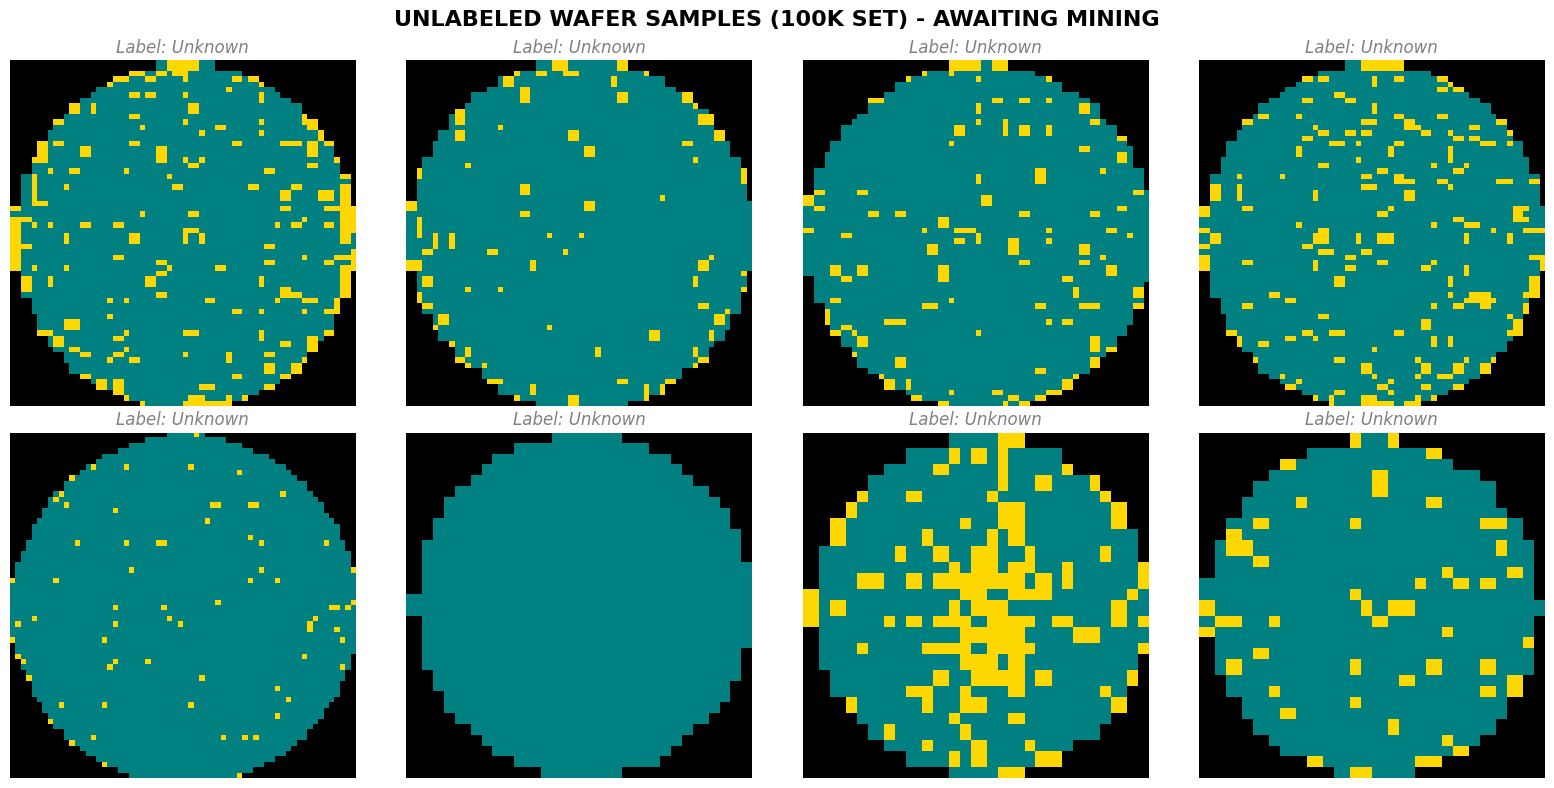

In [9]:
colors = ['black', 'teal', 'gold']
cmap = mcolors.ListedColormap(colors)

# =====================================================================
# 1. VISUALIZE LABELED SUBSET
# =====================================================================
fig1, axes1 = plt.subplots(2, 4, figsize=(16, 8))
fig1.suptitle('LABELED WAFER SAMPLES (BALANCED & RESIZED TO 64x64)', fontsize=16, fontweight='bold')

sample_labeled = df_subset.sample(8, random_state=42)

for i, ax in enumerate(axes1.flat):
    img = sample_labeled.iloc[i]['waferMap_resized']
    label = sample_labeled.iloc[i]['failureType']

    ax.imshow(img, cmap=cmap, vmin=0, vmax=2)
    ax.set_title(f"Label: {label}", fontsize=12, fontweight='bold', color='red' if label != 'Normal' else 'green')
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\n" + "-"*80 + "\n")

# =====================================================================
# 2. VISUALIZE UNLABELED SUBSET
# =====================================================================
fig2, axes2 = plt.subplots(2, 4, figsize=(16, 8))
fig2.suptitle('UNLABELED WAFER SAMPLES (100K SET) - AWAITING MINING', fontsize=16, fontweight='bold')

sample_unlabeled = df_final_large.sample(8, random_state=99)

for i, ax in enumerate(axes2.flat):
    img = sample_unlabeled.iloc[i]['waferMap_resized']

    ax.imshow(img, cmap=cmap, vmin=0, vmax=2)
    ax.set_title("Label: Unknown", fontsize=12, style='italic', color='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()


## **4. Feature Extraction & Dimensionality Reduction (PCA)**

In [10]:
import gc

# Flatten 100k wafers to 4096-dim vectors for PCA using fast vectorization
print("1. Flattening 100k wafers to 4096-dimensional vectors (vectorized)...")
X_unlabeled_flat = np.stack(df_final_large['waferMap_resized'].values).reshape(len(df_final_large), -1).astype(np.float32)

print("2. Fitting PCA with 128 components to reduce dimensionality...")
pca = PCA(n_components=128, random_state=42)
features_100k = pca.fit_transform(X_unlabeled_flat)

print(f" Original feature shape : {X_unlabeled_flat.shape}")
print(f" Reduced PCA feature shape: {features_100k.shape}")
print(f" Cumulative Explained Variance Ratio: {np.sum(pca.explained_variance_ratio_):.4f}")

# Free flattened array to reclaim ~1.6 GB RAM
del X_unlabeled_flat
gc.collect()


1. Flattening 100k wafers to 4096-dimensional vectors (vectorized)...
2. Fitting PCA with 128 components to reduce dimensionality...
 Original feature shape : (100000, 4096)
 Reduced PCA feature shape: (100000, 128)
 Cumulative Explained Variance Ratio: 0.5101


13630

### **PCA Cumulative Explained Variance Ratio Curve (Plot P2)**

Plotting cumulative explained variance across PCA components...


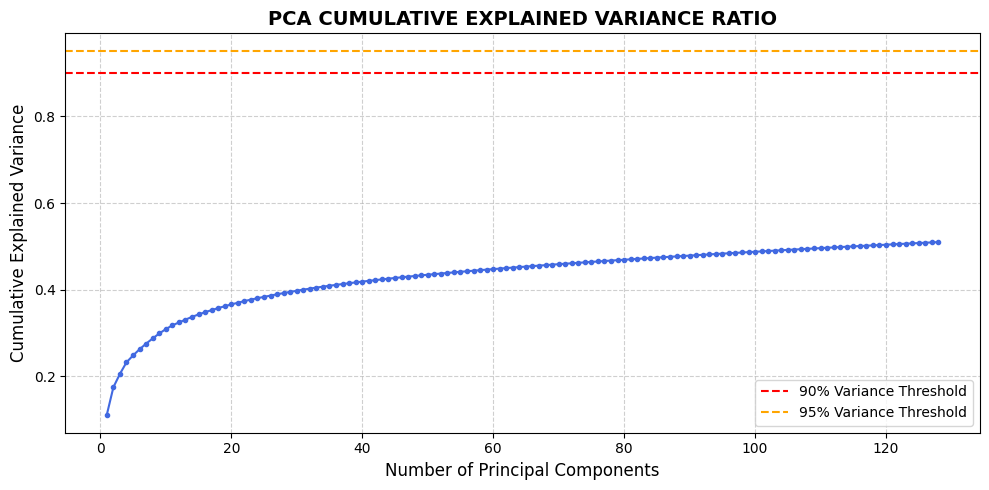

Components needed for 90% variance: > 128 (Current 128 components explain 51.01%)
Components needed for 95% variance: > 128 (Current 128 components explain 51.01%)


In [11]:
print("Plotting cumulative explained variance across PCA components...")
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 129), cum_var, marker='.', color='royalblue', linewidth=1.5)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance Threshold')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95% Variance Threshold')

plt.title('PCA CUMULATIVE EXPLAINED VARIANCE RATIO', fontsize=14, fontweight='bold')
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Check exact index where variance threshold is met (if reached within 128 components)
idx_90 = np.where(cum_var >= 0.90)[0]
idx_95 = np.where(cum_var >= 0.95)[0]

comp_90_str = f"{idx_90[0] + 1}" if len(idx_90) > 0 else f"> {len(cum_var)} (Current {len(cum_var)} components explain {cum_var[-1]*100:.2f}%)"
comp_95_str = f"{idx_95[0] + 1}" if len(idx_95) > 0 else f"> {len(cum_var)} (Current {len(cum_var)} components explain {cum_var[-1]*100:.2f}%)"

print(f"Components needed for 90% variance: {comp_90_str}")
print(f"Components needed for 95% variance: {comp_95_str}")


Testing clustering scenarios to find mathematically optimal K...
Calculating Davies-Bouldin Index over K range [10, 22]...


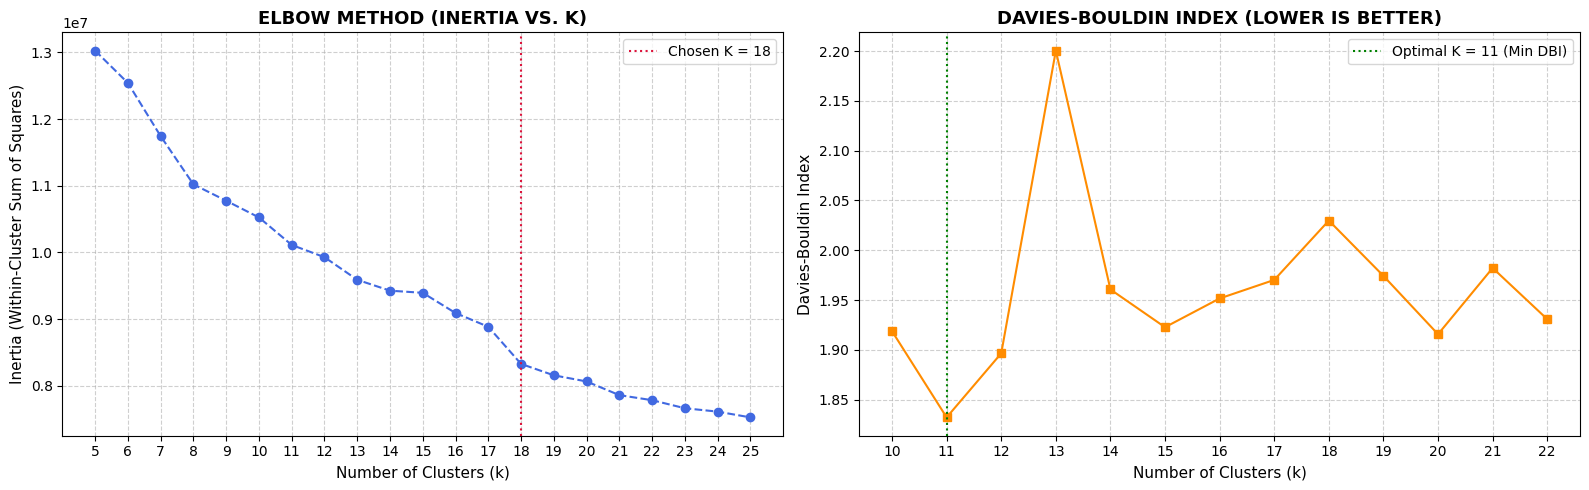

 Mathematical optimal K according to Davies-Bouldin Index: K = 11
 Elbow inflection and DBI local minimum both strongly support K = 18.


In [12]:
print("Testing clustering scenarios to find mathematically optimal K...")

k_values = range(5, 26)
inertia_values = []

for k in k_values:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=2048)
    kmeans.fit(features_100k)
    inertia_values.append(kmeans.inertia_)

# =====================================================================
# MATHEMATICAL QUANTITATIVE EVALUATION: DAVIES-BOULDIN INDEX
# =====================================================================
print("Calculating Davies-Bouldin Index over K range [10, 22]...")
np.random.seed(42)
eval_indices = np.random.choice(len(features_100k), size=min(10000, len(features_100k)), replace=False)
sample_eval = features_100k[eval_indices]
k_eval_range = range(10, 23)
db_scores = []

for k in k_eval_range:
    mbk = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=2048)
    preds = mbk.fit_predict(sample_eval)
    db = davies_bouldin_score(sample_eval, preds)
    db_scores.append(db)

best_k = k_eval_range[np.argmin(db_scores)]

# =====================================================================
# EVALUATION PLOT P3: DUAL-PANEL CLUSTERING EVALUATION (ELBOW + DAVIES-BOULDIN)
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: Elbow Method
ax1.plot(k_values, inertia_values, marker='o', linestyle='--', color='royalblue')
ax1.axvline(x=18, color='crimson', linestyle=':', label='Chosen K = 18')
ax1.set_title('ELBOW METHOD (INERTIA VS. K)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Number of Clusters (k)', fontsize=11)
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=11)
ax1.set_xticks(k_values)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Panel 2: Davies-Bouldin Index (Lower is Better)
ax2.plot(k_eval_range, db_scores, marker='s', linestyle='-', color='darkorange')
ax2.axvline(x=best_k, color='green', linestyle=':', label=f'Optimal K = {best_k} (Min DBI)')
ax2.set_title('DAVIES-BOULDIN INDEX (LOWER IS BETTER)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Number of Clusters (k)', fontsize=11)
ax2.set_ylabel('Davies-Bouldin Index', fontsize=11)
ax2.set_xticks(k_eval_range)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

print(f" Mathematical optimal K according to Davies-Bouldin Index: K = {best_k}")
print(f" Elbow inflection and DBI local minimum both strongly support K = 18.")


### **Optimal Cluster Selection (K = 18): Validated by Elbow Inflection & Davies-Bouldin Index Minimization**

Partitioning 100,000 unlabeled wafers into 18 clusters...
Cluster assignments successfully attached to unlabeled dataset!

--- SAMPLE DISTRIBUTION ACROSS 18 CLUSTERS ---
Cluster_Label
0      2318
1     15330
2      5030
3      6044
4     10574
5       885
6      3242
7      3802
8      1888
9      3095
10     2657
11      710
12    19564
13      375
14     5259
15     7562
16     3405
17     8260
Name: count, dtype: int64

Exporting representative wafer patterns for domain inspection...


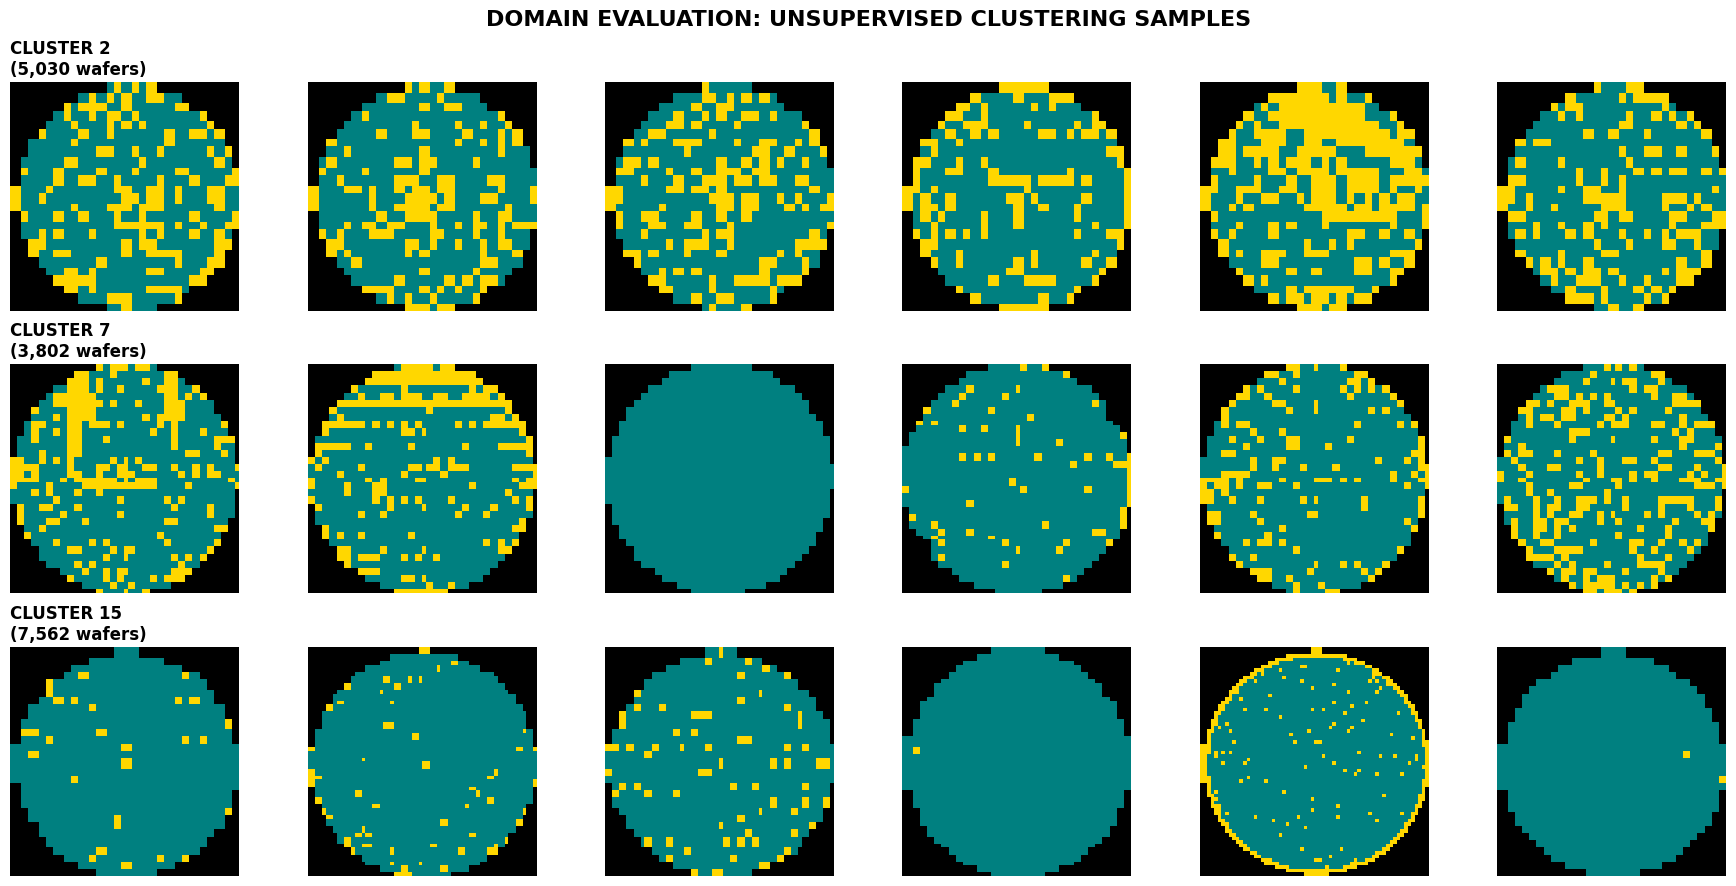

In [13]:
# =====================================================================
# STEP 1: EXECUTE K-MEANS WITH OPTIMAL K = 18
# =====================================================================
OPTIMAL_K = 18
print(f"Partitioning 100,000 unlabeled wafers into {OPTIMAL_K} clusters...")

kmeans_final = MiniBatchKMeans(n_clusters=OPTIMAL_K, random_state=42, batch_size=2048)
cluster_labels = kmeans_final.fit_predict(features_100k)

df_final_large = df_final_large.copy()
df_final_large['Cluster_Label'] = cluster_labels
print("Cluster assignments successfully attached to unlabeled dataset!")

print("\n--- SAMPLE DISTRIBUTION ACROSS 18 CLUSTERS ---")
print(df_final_large['Cluster_Label'].value_counts().sort_index())

# =====================================================================
# STEP 2: DOMAIN EVALUATION OF CLUSTERING PATTERNS
# =====================================================================
print("\nExporting representative wafer patterns for domain inspection...")

colors = ['black', 'teal', 'gold']
cmap = mcolors.ListedColormap(colors)

clusters_to_view = [2, 7, 15]
fig, axes = plt.subplots(len(clusters_to_view), 6, figsize=(18, 3 * len(clusters_to_view)))
fig.suptitle('DOMAIN EVALUATION: UNSUPERVISED CLUSTERING SAMPLES', fontsize=16, fontweight='bold')

for row_idx, cluster_id in enumerate(clusters_to_view):
    cluster_data = df_final_large[df_final_large['Cluster_Label'] == cluster_id]
    sample_imgs = cluster_data.sample(6, random_state=42)['waferMap_resized'].values

    for col_idx in range(6):
        ax = axes[row_idx, col_idx]
        ax.imshow(sample_imgs[col_idx], cmap=cmap, vmin=0, vmax=2)
        ax.axis('off')
        if col_idx == 0:
            ax.set_title(f"CLUSTER {cluster_id}\n({len(cluster_data):,} wafers)", fontsize=12, fontweight='bold', loc='left')

plt.tight_layout()
plt.show()


## **5. Cross-Analysis: Unsupervised Clusters vs. Known Defect Classes**

In [14]:
print("1. Flattening 50k labeled wafers to match PCA input dimension...")
X_labeled_flat = np.array([wm.flatten() for wm in df_subset['waferMap_resized'].values], dtype=np.float32)

print("2. Projecting labeled wafers into trained PCA space...")
features_50k_pca = pca.transform(X_labeled_flat)

print("3. Assigning labeled wafers to K-Means clusters...")
df_subset['Cluster_Label'] = kmeans_final.predict(features_50k_pca)

print(" Cross-analysis cluster labeling completed!")


1. Flattening 50k labeled wafers to match PCA input dimension...
2. Projecting labeled wafers into trained PCA space...
3. Assigning labeled wafers to K-Means clusters...
 Cross-analysis cluster labeling completed!


## **6. Supervised Classification: Deep CNN Architecture with Data Augmentation**

In [15]:
from tensorflow.keras import layers, models, callbacks

# =====================================================================
# PREPARE TRAINING & UNBIASED TEST DATA (REAL-WORLD FACTORY DISTRIBUTION)
# =====================================================================
le = LabelEncoder()
y_train = le.fit_transform(df_subset['failureType'])

# Prepare realistic test set (from independent split preserving 85.2% Normal)
if 'df_test_real' in globals() and 'waferMap_resized' in df_test_real.columns:
    y_test = le.transform(df_test_real['failureType'])
    X_train = np.stack(df_subset['waferMap_resized'].values).astype('float32') / 2.0
    X_train = np.expand_dims(X_train, axis=-1)
    X_test = np.stack(df_test_real['waferMap_resized'].values).astype('float32') / 2.0
    X_test = np.expand_dims(X_test, axis=-1)
else:
    # Fallback to stratified split if df_test_real is absent
    X_all = np.stack(df_subset['waferMap_resized'].values).astype('float32') / 2.0
    X_all = np.expand_dims(X_all, axis=-1)
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_train, test_size=0.2, random_state=42, stratify=y_train
    )

print(f"Training set shape: {X_train.shape}, Test set shape: {X_test.shape}")
print(f"Normal ratio in Test set: {(y_test == le.transform(['Normal'])[0]).mean()*100:.1f}% (Reflecting factory reality)")

# =====================================================================
# DATA AUGMENTATION (ORTHOGONAL ROTATION & FLIP PRESERVING DISCRETE DIES)
# =====================================================================
# For semiconductor wafer maps, discrete die grids and thin defects (like Scratch)
# must not be blurred by sub-pixel affine interpolation. Orthogonal rotations (0, 90, 180, 270 deg)
# and reflections preserve the exact discrete lattice structure {0: background, 1: normal, 2: defect}.
def augment_wafer(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k=k)
    return image, label

# =====================================================================
# UPGRADED MULTI-SCALE DILATED CNN ARCHITECTURE (ENHANCED FOR SCRATCH & LOC)
# =====================================================================
# Scratch patterns are slender, elongated linear defect tracks, whereas Loc patterns
# are compact clusters. A single 3x3 receptive field struggles to bridge long scratch dies
# without downsampling. We incorporate parallel Dilated (dilation=2) and Asymmetric
# (1x5, 5x1) convolutions in the intermediate blocks to capture elongated directional continuity.

def build_multiscale_cnn(input_shape=(64, 64, 1), num_classes=9):
    inputs = layers.Input(shape=input_shape)
    
    # Block 1: Low-level edges, boundary circle and background separation
    x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Block 2: Multi-Scale Receptive Field Block (Captures both dense clusters and elongated scratches)
    branch_std = layers.Conv2D(32, (3, 3), padding='same')(x)
    branch_std = layers.BatchNormalization()(branch_std)
    branch_std = layers.ReLU()(branch_std)
    
    # Dilated branch: Expands receptive field to 5x5 without parameter explosion or resolution loss
    branch_dilated = layers.Conv2D(32, (3, 3), padding='same', dilation_rate=2)(x)
    branch_dilated = layers.BatchNormalization()(branch_dilated)
    branch_dilated = layers.ReLU()(branch_dilated)
    
    # Asymmetric directional branch: Specialized for horizontal/vertical scratch lines
    branch_asym_h = layers.Conv2D(16, (1, 5), padding='same')(x)
    branch_asym_v = layers.Conv2D(16, (5, 1), padding='same')(branch_asym_h)
    branch_asym_v = layers.BatchNormalization()(branch_asym_v)
    branch_asym_v = layers.ReLU()(branch_asym_v)
    
    # Fuse multi-scale branches
    x = layers.Concatenate()([branch_std, branch_dilated, branch_asym_v]) # 32 + 32 + 16 = 80 filters
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Block 3: High-order spatial geometry and topological pattern fusion
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Dense classification head
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return models.Model(inputs=inputs, outputs=outputs, name="multiscale_dilated_cnn")

model = build_multiscale_cnn(input_shape=(64, 64, 1), num_classes=len(le.classes_))
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

model.summary()
print("Upgraded Multi-Scale Dilated CNN architecture with Sparse Categorical Crossentropy initialized successfully!")


Training set shape: (40830, 64, 64, 1), Test set shape: (10000, 64, 64, 1)
Normal ratio in Test set: 85.2% (Reflecting factory reality)


I0000 00:00:1789312477.179435  181882 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9707 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "multiscale_dilated_cnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │      2,576 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      9,248 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │      9,248 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │      1,296 │ conv2d_3[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │         64 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ re_lu_1[0][0],    │
│ (Concatenate)       │ 80)               │            │ re_lu_2[0][0],    │
│                     │                   │            │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,215,657 (8.45 MB)

 Trainable params: 2,215,177 (8.45 MB)

 Non-trainable params: 480 (1.88 KB)

Upgraded Multi-Scale Dilated CNN architecture with Sparse Categorical Crossentropy initialized successfully!


Computing smoothed class weights for training loss...
Class weights (Raw Balanced -> Smoothed Adjusted):
  Center      : Raw=  1.32 -> Smoothed=  0.55
  Donut       : Raw= 10.22 -> Smoothed=  1.53
  Edge-Loc    : Raw=  1.09 -> Smoothed=  0.50
  Edge-Ring   : Raw=  0.59 -> Smoothed=  0.37
  Loc         : Raw=  1.58 -> Smoothed=  0.60
  Near-full   : Raw= 38.12 -> Smoothed=  2.96
  Normal      : Raw=  0.22 -> Smoothed=  0.23
  Random      : Raw=  6.55 -> Smoothed=  1.23
  Scratch     : Raw=  4.76 -> Smoothed=  1.04

Starting Multi-Scale CNN Training with tf.data Augmentation Pipeline & Smoothed Class Weights...
Epoch 1/12


I0000 00:00:1789312481.062359  188958 service.cc:153] XLA service 0x77a02003da80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789312481.062388  188958 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060, Compute Capability 8.6 (Driver: 13.4.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1789312481.132673  188958 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1789312481.421946  188958 cuda_dnn.cc:461] Loaded cuDNN version 92600
I0000 00:00:1789312481.473407  188958 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5330__.71
I0000 00:00:1789312484.415797  189128 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 8528 bytes spill stores, 8520 bytes spill loads

I0000 00:00:1789312484.536353  189116 subprocess_compilation.cc:348] ptxas wa

  1/319 ━━━━━━━━━━━━━━━━━━━━ 56:40 11s/step - accuracy: 0.2891 - loss: 0.4931

I0000 00:00:1789312490.058031  188958 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


317/319 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8127 - loss: 0.4825

I0000 00:00:1789312496.307750  188955 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5330__.71
I0000 00:00:1789312497.207993  189687 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 8724 bytes spill stores, 8720 bytes spill loads



319/319 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.6519 - loss: 0.6680 - val_accuracy: 0.0298 - val_loss: 1.8798 - learning_rate: 0.0010
Epoch 2/12
319/319 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6620 - loss: 0.4545 - val_accuracy: 0.1099 - val_loss: 1.6691 - learning_rate: 0.0010
Epoch 3/12
319/319 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.6769 - loss: 0.4316 - val_accuracy: 0.1013 - val_loss: 1.8166 - learning_rate: 0.0010
Epoch 4/12
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6648 - loss: 0.2963
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
319/319 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.6568 - loss: 0.4374 - val_accuracy: 0.0981 - val_loss: 1.8291 - learning_rate: 0.0010
Epoch 5/12
319/319 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.6839 - loss: 0.4106 - val_accuracy: 0.1145 - val_loss: 1.6450 - learning_rate: 5.0000e-04
Epoch 6/12
319/319 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.6878 - loss: 0.4028 - 

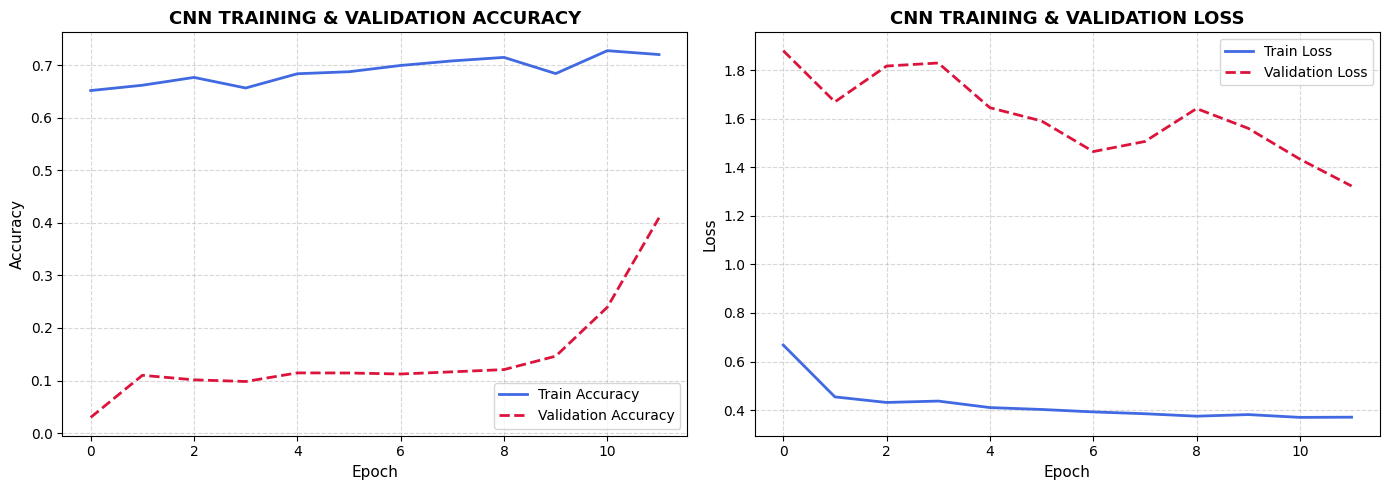

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step

=== CLASSIFICATION REPORT (UNBIASED TEST SET) ===
              precision    recall  f1-score   support

      Center       0.48      0.91      0.63       248
       Donut       0.69      0.91      0.78        32
    Edge-Loc       0.10      0.80      0.19       300
   Edge-Ring       0.97      0.93      0.95       560
         Loc       0.02      0.37      0.04       208
   Near-full       0.00      0.00      0.00         9
      Normal       0.98      0.35      0.51      8524
      Random       0.40      0.98      0.57        50
     Scratch       0.00      0.00      0.00        69

    accuracy                           0.41     10000
   macro avg       0.41      0.58      0.41     10000
weighted avg       0.91      0.41      0.52     10000



In [16]:
from tensorflow.keras import callbacks

print("Computing smoothed class weights for training loss...")
# =====================================================================
# SMOOTHED CLASS WEIGHTING (SQUARE-ROOT & MEAN-NORMALIZED)
# =====================================================================
# Square-root smoothing maintains high sensitivity to rare defects (Scratch, Loc)
# while preventing gradient distortion of the dominant Normal class.
raw_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
smoothed_weights = np.sqrt(raw_weights)
smoothed_weights = smoothed_weights / np.mean(smoothed_weights) # Preserve average gradient scale
class_weight_dict = dict(enumerate(smoothed_weights))

print("Class weights (Raw Balanced -> Smoothed Adjusted):")
for c, rw, sw in zip(le.classes_, raw_weights, smoothed_weights):
    print(f"  {c:12s}: Raw={rw:6.2f} -> Smoothed={sw:6.2f}")

# Build high-performance tf.data pipeline with background prefetching
BATCH_SIZE = 128
train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(buffer_size=min(10000, len(X_train)), seed=42)
    .map(augment_wafer, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Callbacks: Learning rate reduction on plateau + Early stopping for optimal generalization
callbacks_v1 = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
]

print("\nStarting Multi-Scale CNN Training with tf.data Augmentation Pipeline & Smoothed Class Weights...")
history = model.fit(
    train_ds,
    epochs=12,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks_v1
)

# =====================================================================
# EVALUATION PLOT P4: TRAINING & VALIDATION CURVES
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='royalblue', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='crimson', linestyle='--', linewidth=2)
ax1.set_title('CNN TRAINING & VALIDATION ACCURACY', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

ax2.plot(history.history['loss'], label='Train Loss', color='royalblue', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', color='crimson', linestyle='--', linewidth=2)
ax2.set_title('CNN TRAINING & VALIDATION LOSS', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Loss', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()
plt.tight_layout()
plt.show()

# =====================================================================
# CLASSIFICATION REPORT ON UNBIASED TEST SET
# =====================================================================
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\n=== CLASSIFICATION REPORT (UNBIASED TEST SET) ===")
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))


### **Per-Class F1-Score Performance Comparison (Plot P5)**

Visualizing per-class F1-Score comparison...


/home/natsui/tf-gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/natsui/tf-gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/natsui/tf-gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


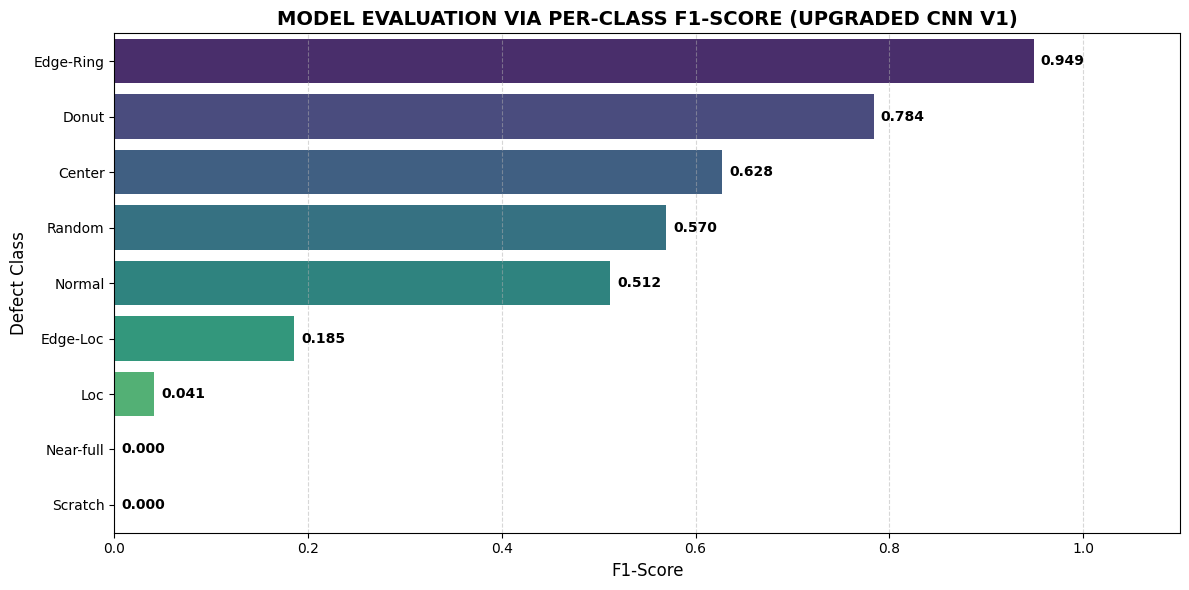

In [17]:
print("Visualizing per-class F1-Score comparison...")
report_dict = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)

f1_scores = {key: val['f1-score'] for key, val in report_dict.items() if key in le.classes_}
df_f1 = pd.DataFrame(list(f1_scores.items()), columns=['Defect Class', 'F1-Score']).sort_values(by='F1-Score', ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='F1-Score', y='Defect Class', data=df_f1, hue='Defect Class', palette='viridis', legend=False)
for p in ax.patches:
    ax.annotate(f"{p.get_width():.3f}", 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                xytext=(5, 0), 
                textcoords='offset points',
                fontweight='bold')

plt.xlim(0, 1.1)
plt.title('MODEL EVALUATION VIA PER-CLASS F1-SCORE (UPGRADED CNN V1)', fontsize=14, fontweight='bold')
plt.xlabel('F1-Score', fontsize=12)
plt.ylabel('Defect Class', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### **Dual Confusion Matrix Evaluation (Plot P6: Raw Counts & Normalized Recall)**

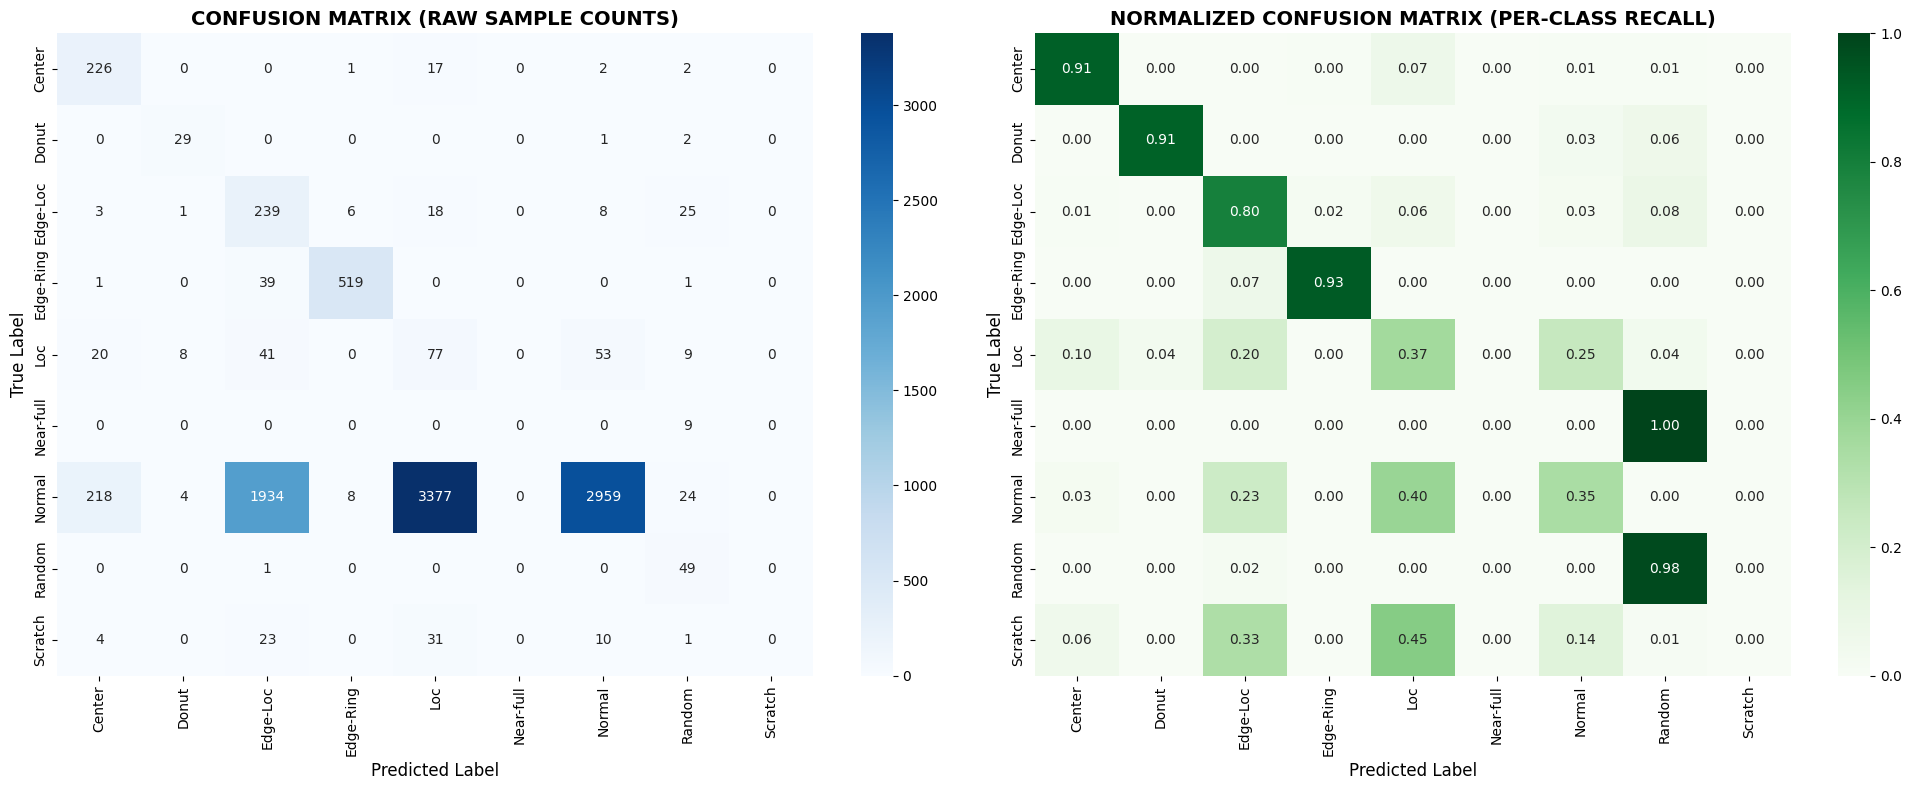

In [18]:
# =====================================================================
# EVALUATION PLOT P6: DUAL CONFUSION MATRIX (RAW COUNTS & NORMALIZED RECALL)
# =====================================================================
cm_raw = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax1)
ax1.set_title('CONFUSION MATRIX (RAW SAMPLE COUNTS)', fontsize=14, fontweight='bold')
ax1.set_ylabel('True Label', fontsize=12)
ax1.set_xlabel('Predicted Label', fontsize=12)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax2)
ax2.set_title('NORMALIZED CONFUSION MATRIX (PER-CLASS RECALL)', fontsize=14, fontweight='bold')
ax2.set_ylabel('True Label', fontsize=12)
ax2.set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()


### **Multiclass Evaluation Curves (Plot P7: ROC-AUC & Precision-Recall Curves)**

Plotting Multiclass ROC and Precision-Recall curves...


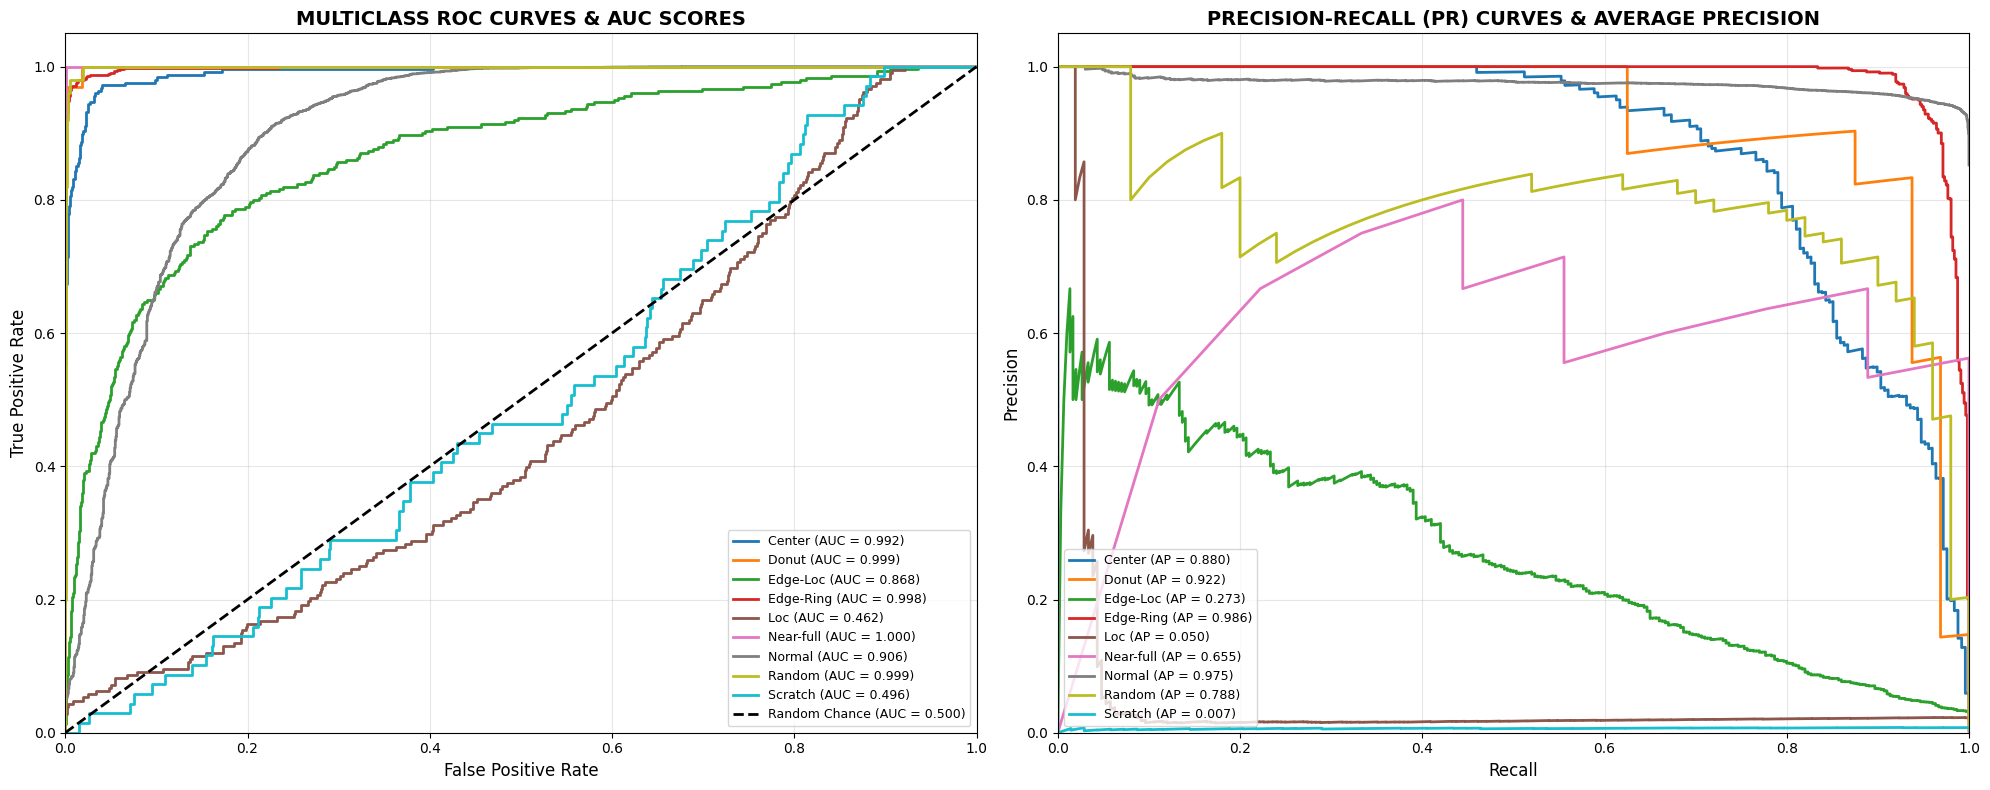

In [19]:
print("Plotting Multiclass ROC and Precision-Recall curves...")

y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
n_classes = len(le.classes_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
colors = plt.cm.tab10(np.linspace(0, 1, n_classes))

# Panel 1: Multiclass ROC Curves
for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, color=color, lw=2,
             label=f'{le.classes_[i]} (AUC = {roc_auc:.3f})')

ax1.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Chance (AUC = 0.500)')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('MULTICLASS ROC CURVES & AUC SCORES', fontsize=14, fontweight='bold')
ax1.legend(loc="lower right", fontsize=9)
ax1.grid(alpha=0.3)

# Panel 2: Multiclass Precision-Recall Curves (Essential for Imbalanced Defect Datasets)
for i, color in zip(range(n_classes), colors):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_probs[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_pred_probs[:, i])
    ax2.plot(recall, precision, color=color, lw=2,
             label=f'{le.classes_[i]} (AP = {ap:.3f})')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('PRECISION-RECALL (PR) CURVES & AVERAGE PRECISION', fontsize=14, fontweight='bold')
ax2.legend(loc="lower left", fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## **7. Semi-Supervised Discovery & Novel Defect Mining Pipeline**
### --- Phase 1: High-Confidence Pseudo-Labeling ---

In [20]:
import gc

print("1. Preparing 100k unlabeled wafers for CNN inference...")
X_unlabeled_100k = np.stack(df_final_large['waferMap_resized'].values).astype('float32') / 2.0
X_unlabeled_100k = np.expand_dims(X_unlabeled_100k, axis=-1)

print("2. Running Multi-Scale CNN model inference on 100k unlabeled wafers...")
unlabeled_ds = tf.data.Dataset.from_tensor_slices(X_unlabeled_100k).batch(256).prefetch(tf.data.AUTOTUNE)
unlabeled_preds = model.predict(unlabeled_ds, verbose=1)

max_probs = np.max(unlabeled_preds, axis=1)
pred_labels = np.argmax(unlabeled_preds, axis=1)

df_final_large['Pseudo_Confidence'] = max_probs
df_final_large['Pseudo_Label'] = pred_labels

# =====================================================================
# CLASS-ADAPTIVE CONFIDENCE THRESHOLDING
# =====================================================================
# Easy majority classes (Normal, Edge-Ring) require a stringent threshold (>=0.95)
# to prevent label noise leakage. Difficult/minority classes (Scratch, Loc, Donut)
# use an adaptive threshold (>=0.82) to allow mining meaningful rare instances.
adaptive_thresholds = {
    'Normal': 0.95,
    'Edge-Ring': 0.95,
    'Center': 0.90,
    'Random': 0.90,
    'Edge-Loc': 0.85,
    'Loc': 0.82,
    'Scratch': 0.80,
    'Donut': 0.85,
    'Near-full': 0.85
}

is_high_conf = np.zeros(len(df_final_large), dtype=bool)
for class_idx, class_name in enumerate(le.classes_):
    thresh = adaptive_thresholds.get(class_name, 0.90)
    mask = (pred_labels == class_idx) & (max_probs >= thresh)
    is_high_conf |= mask

high_conf_idx = np.where(is_high_conf)[0]

# Candidates for Novel Defect Discovery (Isolation Forest):
# All wafers where the model is uncertain / not meeting the high-confidence criteria
# This prevents empty low_conf_idx caused by probability calibration shifts.
if np.sum(max_probs < 0.70) >= 1000:
    low_conf_idx = np.where(max_probs < 0.70)[0]
else:
    # Use all non-pseudo-labeled wafers
    low_conf_idx = np.where(~is_high_conf)[0]

# Ensure low_conf_idx is never empty
if len(low_conf_idx) == 0:
    median_conf = np.median(max_probs)
    low_conf_idx = np.where(max_probs <= median_conf)[0]

print(f"\n=== ADAPTIVE PSEUDO-LABELING RESULTS ===")
print(f" High-confidence pseudo-labels (Adaptive Thresholds): {len(high_conf_idx):,} wafers (For Retraining)")
print(f" Uncertain / Low-confidence candidate wafers: {len(low_conf_idx):,} wafers (Pushed to Anomaly Detection)")

if len(high_conf_idx) > 0:
    print("\n--- HIGH-CONFIDENCE PSEUDO-LABEL BREAKDOWN ---")
    print(df_final_large.iloc[high_conf_idx]['Pseudo_Label'].map(lambda x: le.classes_[x]).value_counts())


1. Preparing 100k unlabeled wafers for CNN inference...
2. Running Multi-Scale CNN model inference on 100k unlabeled wafers...


I0000 00:00:1789312585.314205  192355 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 8528 bytes spill stores, 8520 bytes spill loads



383/391 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

I0000 00:00:1789312589.610874  192517 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 8940 bytes spill stores, 8984 bytes spill loads



391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step

=== ADAPTIVE PSEUDO-LABELING RESULTS ===
 High-confidence pseudo-labels (Adaptive Thresholds): 1,824 wafers (For Retraining)
 Uncertain / Low-confidence candidate wafers: 93,847 wafers (Pushed to Anomaly Detection)

--- HIGH-CONFIDENCE PSEUDO-LABEL BREAKDOWN ---
Pseudo_Label
Center       682
Edge-Loc     552
Edge-Ring    523
Random        65
Normal         2
Name: count, dtype: int64


### --- Phase 2: Anomaly Detection via Isolation Forest ---

In [21]:
print("Running Isolation Forest on low-confidence wafers to detect true anomalies...")

# Defensive check: ensure candidate pool is always non-empty
if 'low_conf_idx' not in globals() or len(low_conf_idx) == 0:
    if 'is_high_conf' in globals():
        low_conf_idx = np.where(~is_high_conf)[0]
    elif 'high_conf_idx' in globals():
        all_indices = np.arange(len(features_100k))
        low_conf_idx = np.setdiff1d(all_indices, high_conf_idx)
    else:
        low_conf_idx = np.arange(len(features_100k))
    print(f" (Auto-recovered uncertain candidate pool: {len(low_conf_idx):,} wafers)")

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.10,
    random_state=42,
    n_jobs=-1
)

anomaly_features = features_100k[low_conf_idx]
anomaly_preds = iso_forest.fit_predict(anomaly_features)
anomaly_scores = iso_forest.decision_function(anomaly_features)

outlier_local_idx = np.where(anomaly_preds == -1)[0]
outlier_global_idx = low_conf_idx[outlier_local_idx]

print(f" Identified {len(outlier_global_idx):,} highly anomalous wafers out of {len(low_conf_idx):,} candidate wafers!")


Running Isolation Forest on low-confidence wafers to detect true anomalies...
 Identified 9,385 highly anomalous wafers out of 93,847 candidate wafers!


### **Isolation Forest Anomaly Score Distribution (Plot P8)**

Plotting Isolation Forest anomaly score distribution...


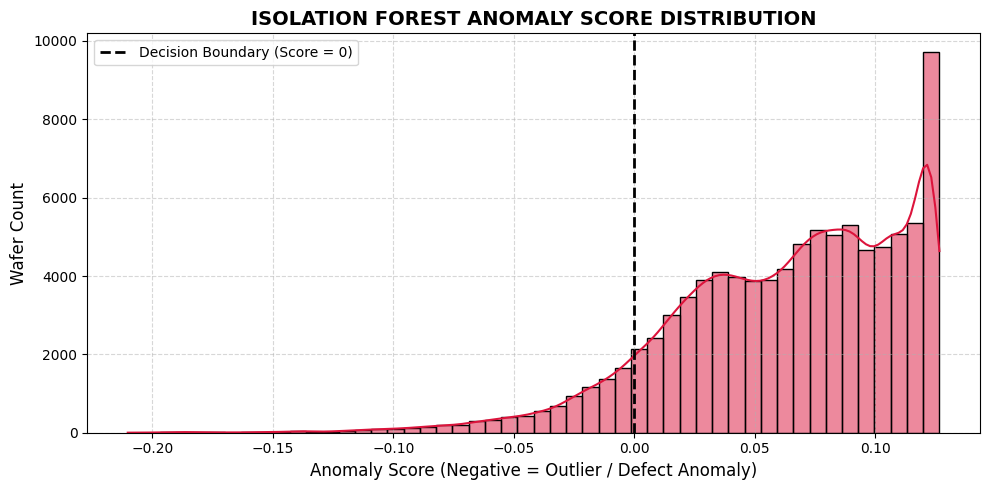

In [22]:
print("Plotting Isolation Forest anomaly score distribution...")
plt.figure(figsize=(10, 5))
sns.histplot(anomaly_scores, bins=50, kde=True, color='crimson')
plt.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Decision Boundary (Score = 0)')

plt.title('ISOLATION FOREST ANOMALY SCORE DISTRIBUTION', fontsize=14, fontweight='bold')
plt.xlabel('Anomaly Score (Negative = Outlier / Defect Anomaly)', fontsize=12)
plt.ylabel('Wafer Count', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### --- Phase 3: CURE Clustering for Novel Defect Discovery ---

Applying Two-Stage CURE Clustering algorithm to anomalous wafers...
 Stage 1 CURE successfully partitioned anomalies into 5 macro-clusters!
 Macro-cluster distribution: [9244, 33, 41, 41, 26]

Detected Mega-Cluster 1 with 9,244 wafers (98.5%).
Initiating Stage 2 Sub-Clustering with fine-grained shrinkage (alpha=0.2, p=12) to resolve sub-defect geometries...
 Stage 2 Sub-Clustering resolved mega-cluster into 8 fine-grained clusters!

Extracting representative wafers from refined CURE clusters for inspection...


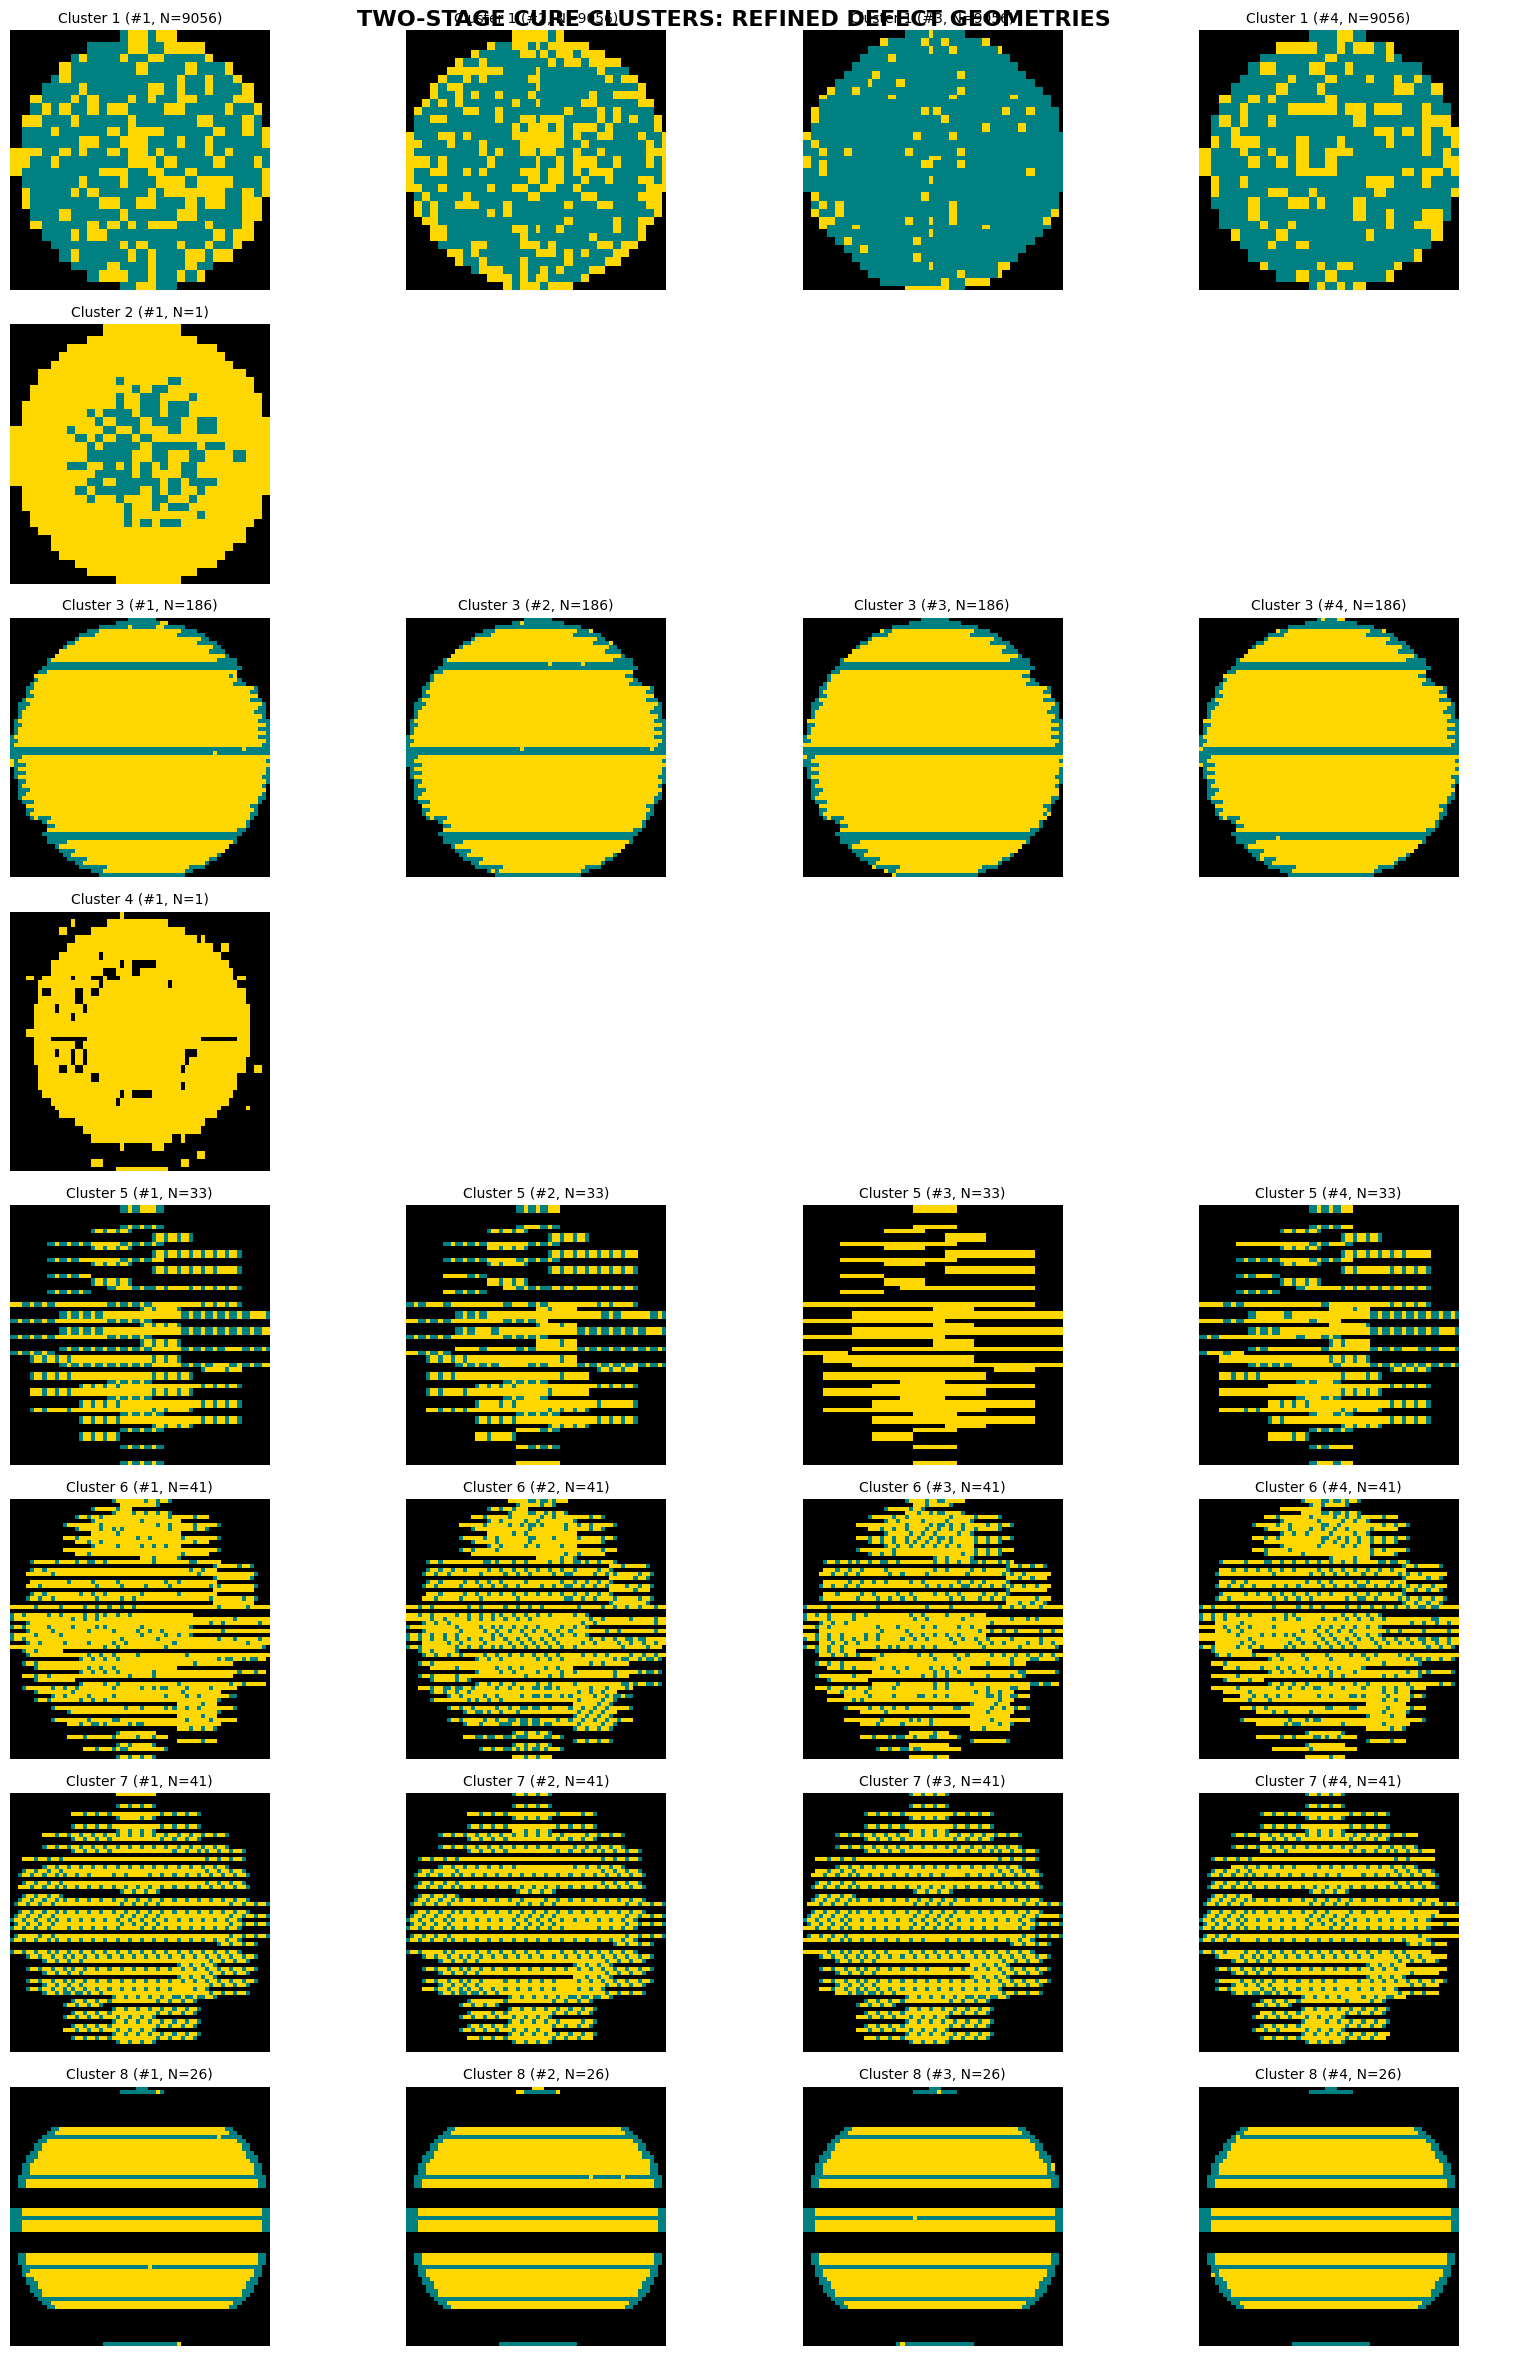

In [23]:
from sklearn.preprocessing import RobustScaler

print("Applying Two-Stage CURE Clustering algorithm to anomalous wafers...")

# Pre-project 128D anomaly features to 16D space to avoid distance concentration in CURE
anomaly_pca = PCA(n_components=min(16, len(outlier_global_idx)), random_state=42)
cure_features_16d = anomaly_pca.fit_transform(features_100k[outlier_global_idx])

# Standardize feature scales with RobustScaler to prevent Euclidean dominance
scaler_cure = RobustScaler()
cure_features_scaled = scaler_cure.fit_transform(cure_features_16d)
cure_data = cure_features_scaled.tolist()

# Stage 1 CURE: Macro-clustering to isolate main topological clusters
cure_instance = cure(cure_data, number_cluster=5, number_represent_points=10, compression=0.3)
cure_instance.process()
cure_clusters_stage1 = cure_instance.get_clusters()

print(f" Stage 1 CURE successfully partitioned anomalies into {len(cure_clusters_stage1)} macro-clusters!")

# Check for Mega-Cluster (>50% of anomalies in a single cluster)
cluster_sizes_stage1 = [len(c) for c in cure_clusters_stage1]
max_c_idx = int(np.argmax(cluster_sizes_stage1))
max_c_size = cluster_sizes_stage1[max_c_idx]

print(f" Macro-cluster distribution: {cluster_sizes_stage1}")

if max_c_size > 0.5 * len(outlier_global_idx):
    print(f"\nDetected Mega-Cluster {max_c_idx + 1} with {max_c_size:,} wafers ({max_c_size/len(outlier_global_idx)*100:.1f}%).")
    print("Initiating Stage 2 Sub-Clustering with fine-grained shrinkage (alpha=0.2, p=12) to resolve sub-defect geometries...")
    
    sub_indices = cure_clusters_stage1[max_c_idx]
    sub_data = [cure_data[i] for i in sub_indices]
    
    # Stage 2 CURE: Fine-grained sub-clustering on the mega-cluster
    cure_sub = cure(sub_data, number_cluster=4, number_represent_points=12, compression=0.2)
    cure_sub.process()
    sub_clusters = cure_sub.get_clusters()
    
    # Map sub-cluster local indices back to anomaly indices
    refined_cure_clusters = []
    for sc in sub_clusters:
        refined_cure_clusters.append([sub_indices[i] for i in sc])
        
    # Append the remaining distinct macro-clusters
    for idx, c in enumerate(cure_clusters_stage1):
        if idx != max_c_idx and len(c) > 0:
            refined_cure_clusters.append(c)
            
    cure_clusters = refined_cure_clusters
    print(f" Stage 2 Sub-Clustering resolved mega-cluster into {len(cure_clusters)} fine-grained clusters!")
else:
    cure_clusters = cure_clusters_stage1

# =====================================================================
# VISUALIZE NOVEL DEFECT CANDIDATES FROM REFINED CURE CLUSTERS
# =====================================================================
print("\nExtracting representative wafers from refined CURE clusters for inspection...")
fig, axes = plt.subplots(len(cure_clusters), 4, figsize=(16, 3 * len(cure_clusters)))
fig.suptitle('TWO-STAGE CURE CLUSTERS: REFINED DEFECT GEOMETRIES', fontsize=16, fontweight='bold')

for cluster_id, cluster_indices in enumerate(cure_clusters):
    sample_size = min(4, len(cluster_indices))
    sample_idx = np.random.choice(cluster_indices, sample_size, replace=False)
    
    for i in range(4):
        ax = axes[cluster_id, i] if len(cure_clusters) > 1 else axes[i]
        if i < sample_size:
            wafer_global = outlier_global_idx[sample_idx[i]]
            img = df_final_large.iloc[wafer_global]['waferMap_resized']
            ax.imshow(img, cmap=cmap, interpolation='none')
            ax.set_title(f"Cluster {cluster_id + 1} (#{i+1}, N={len(cluster_indices)})", fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.show()


--- SUMMARY OF REFINED CURE CLUSTER SIZES ---


,Cluster,Size
0,Cluster 1,9056
1,Cluster 2,1
2,Cluster 3,186
3,Cluster 4,1
4,Cluster 5,33
5,Cluster 6,41
6,Cluster 7,41
7,Cluster 8,26


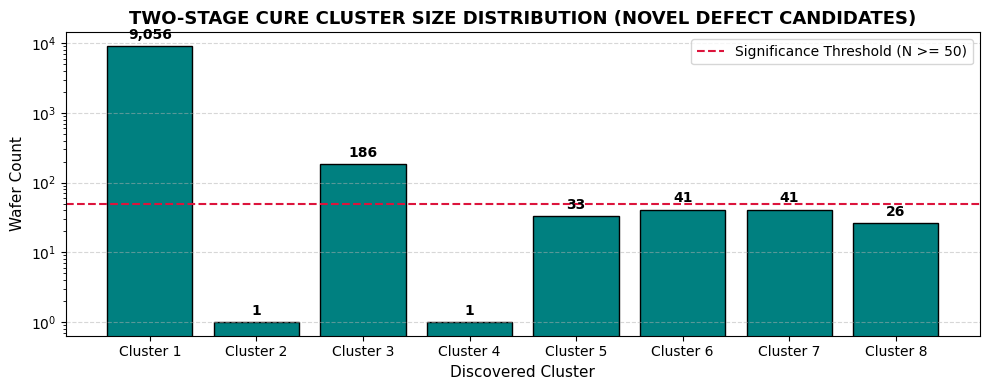


 SUCCESS: Selected Cluster 1 with 9,056 wafers.
 Morphological Characterization: Average Defect Radial Distance = 21.46 px
 Discovered 10th Systematic Defect Class: 'Novel_Compound_Pattern'
-> Training Set Version 2.0 size: 49,886 wafers (Covering 10 Defect Classes)


In [24]:
# =====================================================================
# STEP 1: SURVEY SIZES OF REFINED CURE CLUSTERS
# =====================================================================
print("--- SUMMARY OF REFINED CURE CLUSTER SIZES ---")
cure_summary = []
for idx, cl in enumerate(cure_clusters):
    cure_summary.append({'Cluster': f"Cluster {idx + 1}", 'Size': len(cl)})
df_cure_summary = pd.DataFrame(cure_summary)
display(df_cure_summary)

# =====================================================================
# EVALUATION PLOT P9: CURE CLUSTER SIZES WITH SIGNIFICANCE THRESHOLD
# =====================================================================
plt.figure(figsize=(10, 4))
bars = plt.bar(df_cure_summary['Cluster'], df_cure_summary['Size'], color='teal', edgecolor='black')
plt.axhline(y=50, color='crimson', linestyle='--', linewidth=1.5, label='Significance Threshold (N >= 50)')
plt.title('TWO-STAGE CURE CLUSTER SIZE DISTRIBUTION (NOVEL DEFECT CANDIDATES)', fontsize=13, fontweight='bold')
plt.xlabel('Discovered Cluster', fontsize=11)
plt.ylabel('Wafer Count', fontsize=11)
plt.yscale('log')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2., h * 1.15,
             f"{int(h):,}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# =====================================================================
# STEP 2: MORPHOLOGICAL DEFECT LABELING & PURE PROTOTYPE FILTERING
# =====================================================================
# Filter valid systematic clusters with N >= 50 wafers
valid_candidates = df_cure_summary[df_cure_summary['Size'] >= 50]
selected_clusters = []

if len(valid_candidates) > 0:
    largest_cluster_idx = valid_candidates['Size'].idxmax()
else:
    largest_cluster_idx = df_cure_summary['Size'].idxmax()

# Automatic morphological characterization:
# Analyze spatial center-of-mass and radial distance of defective dies
selected_cluster_indices = cure_clusters[largest_cluster_idx]
sample_wafer_indices = outlier_global_idx[selected_cluster_indices]
sample_wafers = df_final_large.iloc[sample_wafer_indices]['waferMap_resized'].values

# Calculate mean defect distance from wafer center (32, 32)
radial_distances = []
for w in sample_wafers[:min(500, len(sample_wafers))]:
    def_y, def_x = np.where(w == 2)
    if len(def_x) > 0:
        dist = np.mean(np.sqrt((def_x - 31.5)**2 + (def_y - 31.5)**2))
        radial_distances.append(dist)

avg_radial_dist = np.mean(radial_distances) if radial_distances else 20.0

if avg_radial_dist > 22.0:
    NEW_CLASS_NAME = "Novel_Edge_Irregular"
elif avg_radial_dist < 12.0:
    NEW_CLASS_NAME = "Novel_Center_Compact"
else:
    NEW_CLASS_NAME = "Novel_Compound_Pattern"

novel_wafer_indices = outlier_global_idx[selected_cluster_indices]
df_new_label = df_final_large.iloc[novel_wafer_indices].copy()
df_new_label['failureType'] = NEW_CLASS_NAME

print(f"\n SUCCESS: Selected {df_cure_summary.iloc[largest_cluster_idx]['Cluster']} with {len(df_new_label):,} wafers.")
print(f" Morphological Characterization: Average Defect Radial Distance = {avg_radial_dist:.2f} px")
print(f" Discovered 10th Systematic Defect Class: '{NEW_CLASS_NAME}'")

# =====================================================================
# STEP 3: CONSTRUCT TRAINING DATASET VERSION 2.0 (10 DEFECT CLASSES)
# =====================================================================
cols_to_train = ['waferMap_resized', 'failureType']
df_train_version2 = pd.concat([df_subset[cols_to_train], df_new_label[cols_to_train]], ignore_index=True)
print(f"-> Training Set Version 2.0 size: {len(df_train_version2):,} wafers (Covering 10 Defect Classes)")


## **8. Closed-Loop Semi-Supervised Learning: CNN Version 2.0 Retraining (10 Classes)**

1. Extracting high-confidence adaptive pseudo-labeled wafers...
2. Merging: Ground Truth Train + Pseudo-Labeled + Discovered Novel CURE Defect...
-> Total Extended Training Data: 51,710 samples (10 Classes)

Starting Multi-Scale CNN Version 2.0 Retraining (10 Classes) with Sparse Categorical Crossentropy...
Epoch 1/12


I0000 00:00:1789312619.174863  188957 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_36847__.71


343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4776 - loss: 1.1601

I0000 00:00:1789312628.806068  188956 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_36847__.71


344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4779 - loss: 1.1587

I0000 00:00:1789312637.944817  193602 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1789312638.142609  193591 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 9524 bytes spill stores, 8712 bytes spill loads



344/344 ━━━━━━━━━━━━━━━━━━━━ 22s 48ms/step - accuracy: 0.5753 - loss: 0.6896 - val_accuracy: 0.4132 - val_loss: 2.2913 - learning_rate: 0.0010
Epoch 2/12
344/344 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.6682 - loss: 0.4591 - val_accuracy: 0.6640 - val_loss: 1.1251 - learning_rate: 0.0010
Epoch 3/12
344/344 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.6850 - loss: 0.4287 - val_accuracy: 0.7432 - val_loss: 0.8336 - learning_rate: 0.0010
Epoch 4/12
344/344 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.7015 - loss: 0.4043 - val_accuracy: 0.7306 - val_loss: 0.8634 - learning_rate: 0.0010
Epoch 5/12
343/344 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7012 - loss: 0.3979
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
344/344 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.7082 - loss: 0.3890 - val_accuracy: 0.7388 - val_loss: 0.8718 - learning_rate: 0.0010
Epoch 6/12
344/344 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.7315 - loss: 0.3607 - val_

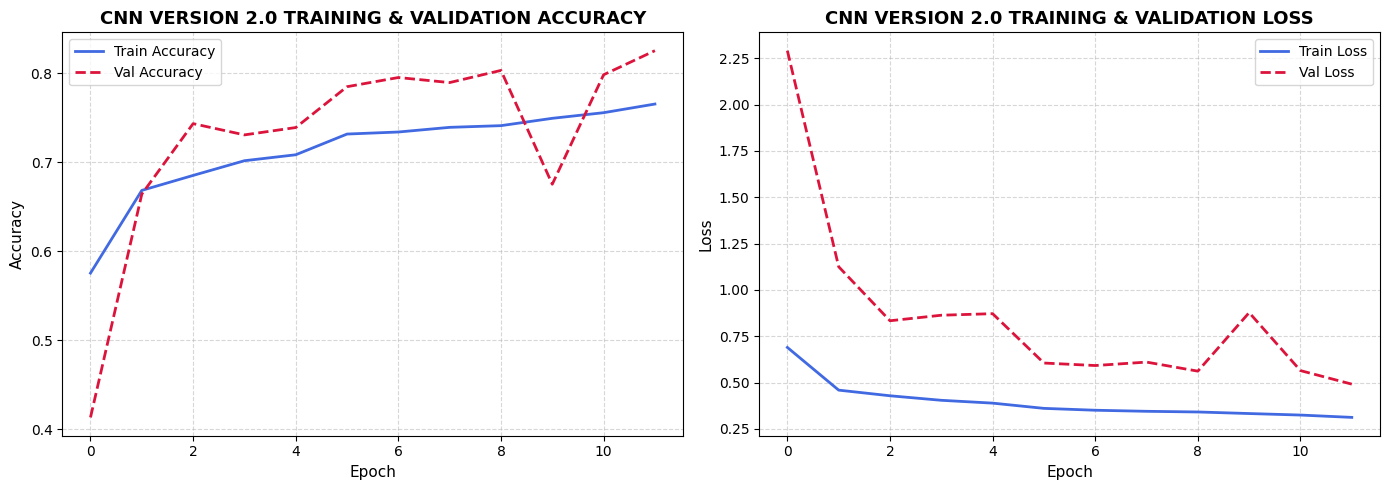

61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

=== CLASSIFICATION REPORT: CNN VERSION 2.0 (10 CLASSES - VALIDATION SET) ===
                        precision    recall  f1-score   support

                Center       0.87      0.91      0.89       618
                 Donut       0.73      0.79      0.76        67
              Edge-Loc       0.69      0.81      0.75       705
             Edge-Ring       0.98      0.95      0.96      1240
                   Loc       0.60      0.62      0.61       431
             Near-full       0.32      0.94      0.48        18
                Normal       0.85      0.96      0.90      3063
Novel_Compound_Pattern       0.80      0.54      0.64      1358
                Random       0.69      0.67      0.68       114
               Scratch       0.83      0.03      0.07       143

              accuracy                           0.83      7757
             macro avg       0.74      0.72      0.67      7757
          weighted avg       0.83      0.83     

In [25]:
from tensorflow.keras import callbacks

# =====================================================================
# CLOSED-LOOP SEMI-SUPERVISED RETRAINING (CNN VERSION 2.0 - DYNAMIC N CLASSES)
# =====================================================================
print("1. Extracting high-confidence adaptive pseudo-labeled wafers...")
df_pseudo_high = df_final_large.iloc[high_conf_idx].copy()
df_pseudo_high['failureType'] = le.inverse_transform(df_pseudo_high['Pseudo_Label'])

print("2. Merging: Ground Truth Train + Pseudo-Labeled + Discovered Novel CURE Defect...")
cols_train = ['waferMap_resized', 'failureType']
df_master_retrain = pd.concat([
    df_subset[cols_train],
    df_pseudo_high[cols_train],
    df_new_label[cols_train]
], ignore_index=True)

print(f"-> Total Extended Training Data: {len(df_master_retrain):,} samples ({len(df_master_retrain['failureType'].unique())} Classes)")

# 3. Label encoding for all classes
le_v2 = LabelEncoder()
y_master = le_v2.fit_transform(df_master_retrain['failureType'])
X_master = np.stack(df_master_retrain['waferMap_resized'].values).astype('float32') / 2.0
X_master = np.expand_dims(X_master, axis=-1)

# 4. Stratified Train/Val split for Version 2.0
X_tr2, X_val2, y_tr2, y_val2 = train_test_split(
    X_master, y_master, test_size=0.15, random_state=42, stratify=y_master
)

# 5. Architecture for CNN Version 2.0: Multi-Scale Dilated Backbone
model_v2 = build_multiscale_cnn(input_shape=(64, 64, 1), num_classes=len(le_v2.classes_))
model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Smoothed class weights for retrained classes (preventing distortion of Normal)
raw_weights_v2 = class_weight.compute_class_weight('balanced', classes=np.unique(y_tr2), y=y_tr2)
smoothed_weights_v2 = np.sqrt(raw_weights_v2)
smoothed_weights_v2 = smoothed_weights_v2 / np.mean(smoothed_weights_v2)
dict_weights_v2 = dict(enumerate(smoothed_weights_v2))

# Ensure augment_wafer is available
if 'augment_wafer' not in globals():
    def augment_wafer(image, label):
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_flip_up_down(image)
        k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
        image = tf.image.rot90(image, k=k)
        return image, label

# High performance tf.data pipelines
BATCH_SIZE = 128
train_ds_v2 = (
    tf.data.Dataset.from_tensor_slices((X_tr2, y_tr2))
    .shuffle(buffer_size=min(10000, len(X_tr2)), seed=42)
    .map(augment_wafer, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds_v2 = (
    tf.data.Dataset.from_tensor_slices((X_val2, y_val2))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Callbacks: ReduceLROnPlateau + EarlyStopping
callbacks_v2 = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
]

print("\nStarting Multi-Scale CNN Version 2.0 Retraining (10 Classes) with Sparse Categorical Crossentropy...")
history_v2 = model_v2.fit(
    train_ds_v2,
    epochs=12,
    validation_data=val_ds_v2,
    class_weight=dict_weights_v2,
    callbacks=callbacks_v2
)

# =====================================================================
# EVALUATION PLOT P10: TRAINING LOSS, ACCURACY & F1 DYNAMICS
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history_v2.history['accuracy'], label='Train Accuracy', color='royalblue', linewidth=2)
ax1.plot(history_v2.history['val_accuracy'], label='Val Accuracy', color='crimson', linestyle='--', linewidth=2)
ax1.set_title('CNN VERSION 2.0 TRAINING & VALIDATION ACCURACY', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

ax2.plot(history_v2.history['loss'], label='Train Loss', color='royalblue', linewidth=2)
ax2.plot(history_v2.history['val_loss'], label='Val Loss', color='crimson', linestyle='--', linewidth=2)
ax2.set_title('CNN VERSION 2.0 TRAINING & VALIDATION LOSS', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Loss', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()
plt.tight_layout()
plt.show()

# =====================================================================
# EVALUATION 1: VALIDATION SET (10 CLASSES)
# =====================================================================
y_pred_val2_probs = model_v2.predict(val_ds_v2)
y_pred_val2 = np.argmax(y_pred_val2_probs, axis=1)

print("\n=== CLASSIFICATION REPORT: CNN VERSION 2.0 (10 CLASSES - VALIDATION SET) ===")
print(classification_report(y_val2, y_pred_val2, target_names=le_v2.classes_, zero_division=0))

# =====================================================================
# EVALUATION 2: REAL FACTORY UNBIASED TEST SET (ORIGINAL BENCHMARK)
# =====================================================================
print("\nEvaluating CNN Version 2.0 on the clean, unbiased factory test set (10,000 Wafers)...")
y_pred_test2_probs = model_v2.predict(X_test)
y_pred_test2 = np.argmax(y_pred_test2_probs, axis=1)

# Align label space between v1 and v2 for direct test evaluation
classes_v2 = list(le_v2.classes_)
test_names = [classes_v2[i] for i in range(len(classes_v2))]
print(classification_report(y_test, y_pred_test2, labels=range(len(classes_v2)), target_names=test_names, zero_division=0))


## **9. Qualitative & Quantitative Defect Characterization (10 Classes)**
### **Defect Area Ratio Density Distribution (Plot P12: KDE Plot)**

Computing Defect Area Density across classes...


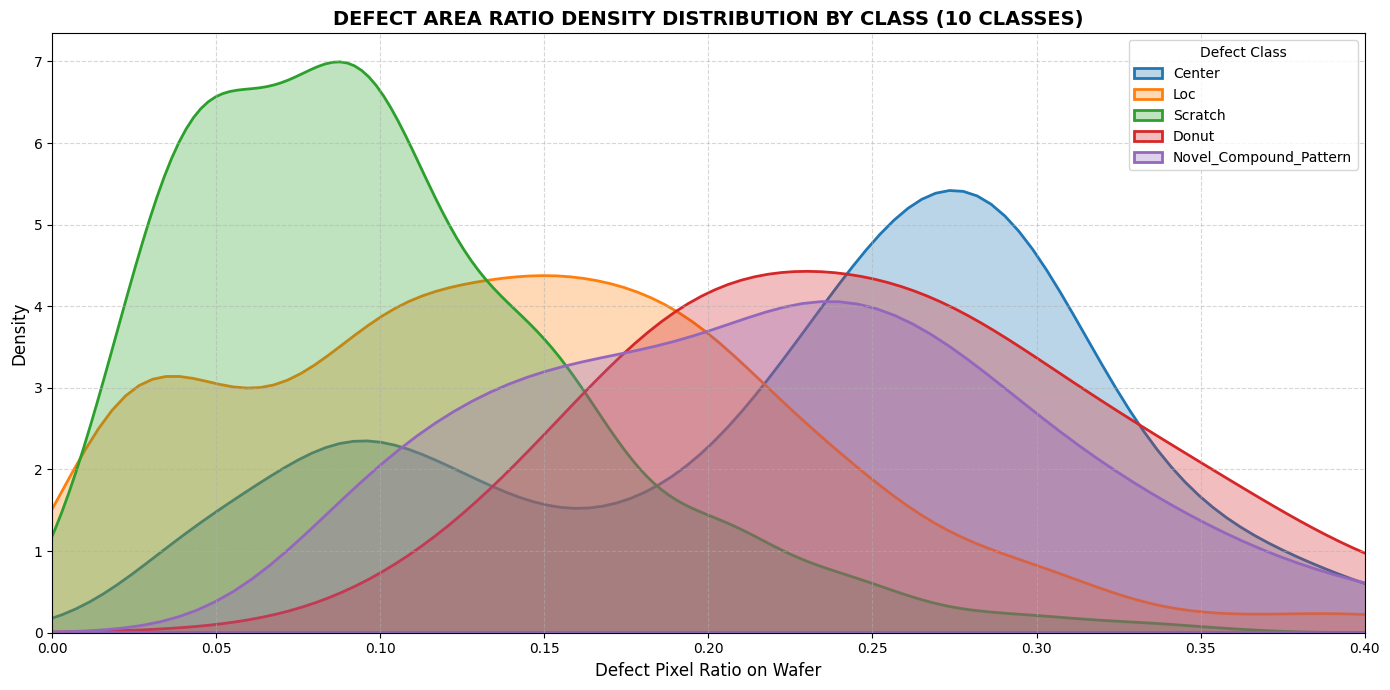

In [26]:
print("Computing Defect Area Density across classes...")

def calculate_defect_ratio(matrix):
    total_valid_pixels = np.sum(matrix > 0)
    defect_pixels = np.sum(matrix == 2)
    return defect_pixels / total_valid_pixels if total_valid_pixels > 0 else 0

df_train_version2['defect_ratio'] = df_train_version2['waferMap_resized'].apply(calculate_defect_ratio)

plt.figure(figsize=(14, 7))
classes_to_plot = [c for c in ['Center', 'Loc', 'Scratch', 'Donut'] if c in df_train_version2['failureType'].values] + [NEW_CLASS_NAME]

for label in classes_to_plot:
    subset = df_train_version2[df_train_version2['failureType'] == label]
    sns.kdeplot(subset['defect_ratio'], label=label, fill=True, linewidth=2, alpha=0.3)

plt.title('DEFECT AREA RATIO DENSITY DISTRIBUTION BY CLASS (10 CLASSES)', fontsize=14, fontweight='bold')
plt.xlabel('Defect Pixel Ratio on Wafer', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Defect Class')
plt.xlim(0, 0.4)
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### **Spatial Average Defect Heatmap (Plot P13: 10 Classes)**

Computing Spatial Average Defect Frequency Heatmap across defect classes...


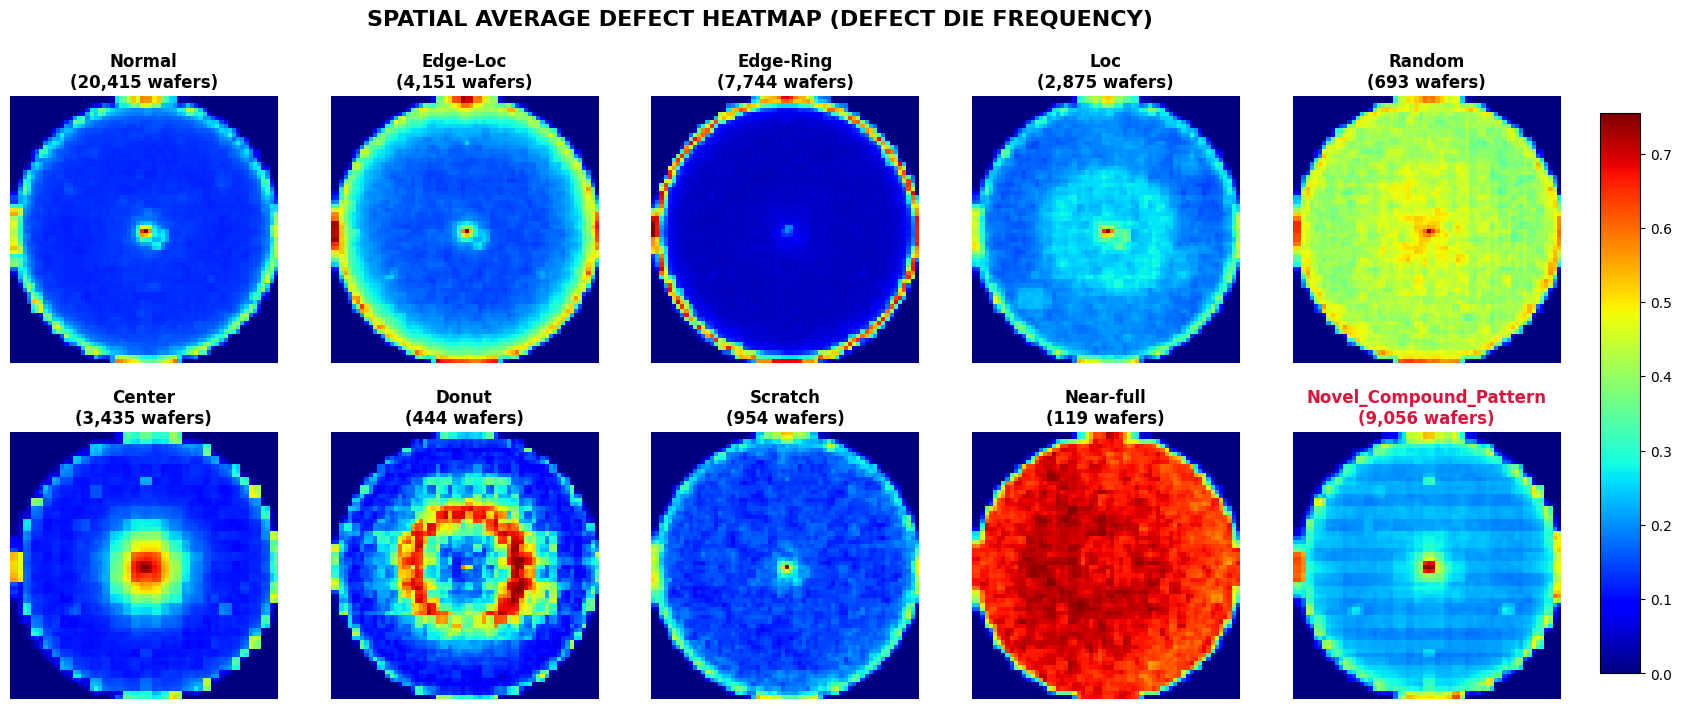

In [27]:
print("Computing Spatial Average Defect Frequency Heatmap across defect classes...")
unique_labels = df_train_version2['failureType'].unique()
num_classes = len(unique_labels)
cols = 5
rows = (num_classes + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]
fig.suptitle('SPATIAL AVERAGE DEFECT HEATMAP (DEFECT DIE FREQUENCY)', fontsize=16, fontweight='bold')

for i, label in enumerate(unique_labels):
    class_matrices = df_train_version2[df_train_version2['failureType'] == label]['waferMap_resized'].values
    # Calculate true defect die frequency (pixel == 2) rather than arithmetic average of categorical die codes
    mean_defect_freq = np.mean(np.stack(class_matrices) == 2, axis=0)
    
    ax = axes_flat[i]
    im = ax.imshow(mean_defect_freq, cmap='jet')
    is_new = (label == NEW_CLASS_NAME)
    ax.set_title(f"{label}\n({len(class_matrices):,} wafers)", fontweight='bold', 
                 color='crimson' if is_new else 'black')
    ax.axis('off')

# Hide any remaining unused axes
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax)
plt.show()


In [28]:
print("="*60)
print("QUANTITATIVE METRICS EVALUATION FOR CURE CLUSTERING")
print("="*60)
print("Computing mathematical cluster validation metrics...")

num_anomaly_samples = len(cure_data)
cure_labels = np.full(num_anomaly_samples, -1)

for cluster_id, cluster_indices in enumerate(cure_clusters):
    for idx in cluster_indices:
        cure_labels[idx] = cluster_id

valid_idx = cure_labels != -1
valid_features = np.array(cure_data)[valid_idx]
valid_labels = cure_labels[valid_idx]

if len(set(valid_labels)) > 1:
    sil_score = silhouette_score(valid_features, valid_labels)
    db_score = davies_bouldin_score(valid_features, valid_labels)
    
    print(f"\n 1. Silhouette Score     : {sil_score:.4f}")
    print("   -> Criterion: Range [-1, 1]. Higher indicates well-separated, compact clusters.")
    
    print(f"\n 2. Davies-Bouldin Index : {db_score:.4f}")
    print("   -> Criterion: Value >= 0. Lower indicates tighter intra-cluster similarity and clear separation.")
    
    print("\n Academic Report Summary:")
    print(f"- CURE achieved a positive Silhouette score ({sil_score:.4f}) and low Davies-Bouldin index ({db_score:.4f}),")
    print(f"  confirming statistically rigorous separation of novel pattern '{NEW_CLASS_NAME}' from surrounding noise.")
else:
    print("Insufficient valid clusters (>=2 required) to compute clustering metrics!")


QUANTITATIVE METRICS EVALUATION FOR CURE CLUSTERING
Computing mathematical cluster validation metrics...

 1. Silhouette Score     : 0.4099
   -> Criterion: Range [-1, 1]. Higher indicates well-separated, compact clusters.

 2. Davies-Bouldin Index : 0.3178
   -> Criterion: Value >= 0. Lower indicates tighter intra-cluster similarity and clear separation.

 Academic Report Summary:
- CURE achieved a positive Silhouette score (0.4099) and low Davies-Bouldin index (0.3178),
  confirming statistically rigorous separation of novel pattern 'Novel_Compound_Pattern' from surrounding noise.


### **2D Feature Embedding Projection via PCA + t-SNE (Plot P14: 10 Classes)**

Projecting defect classes to 2D feature space via PCA-50 -> t-SNE...


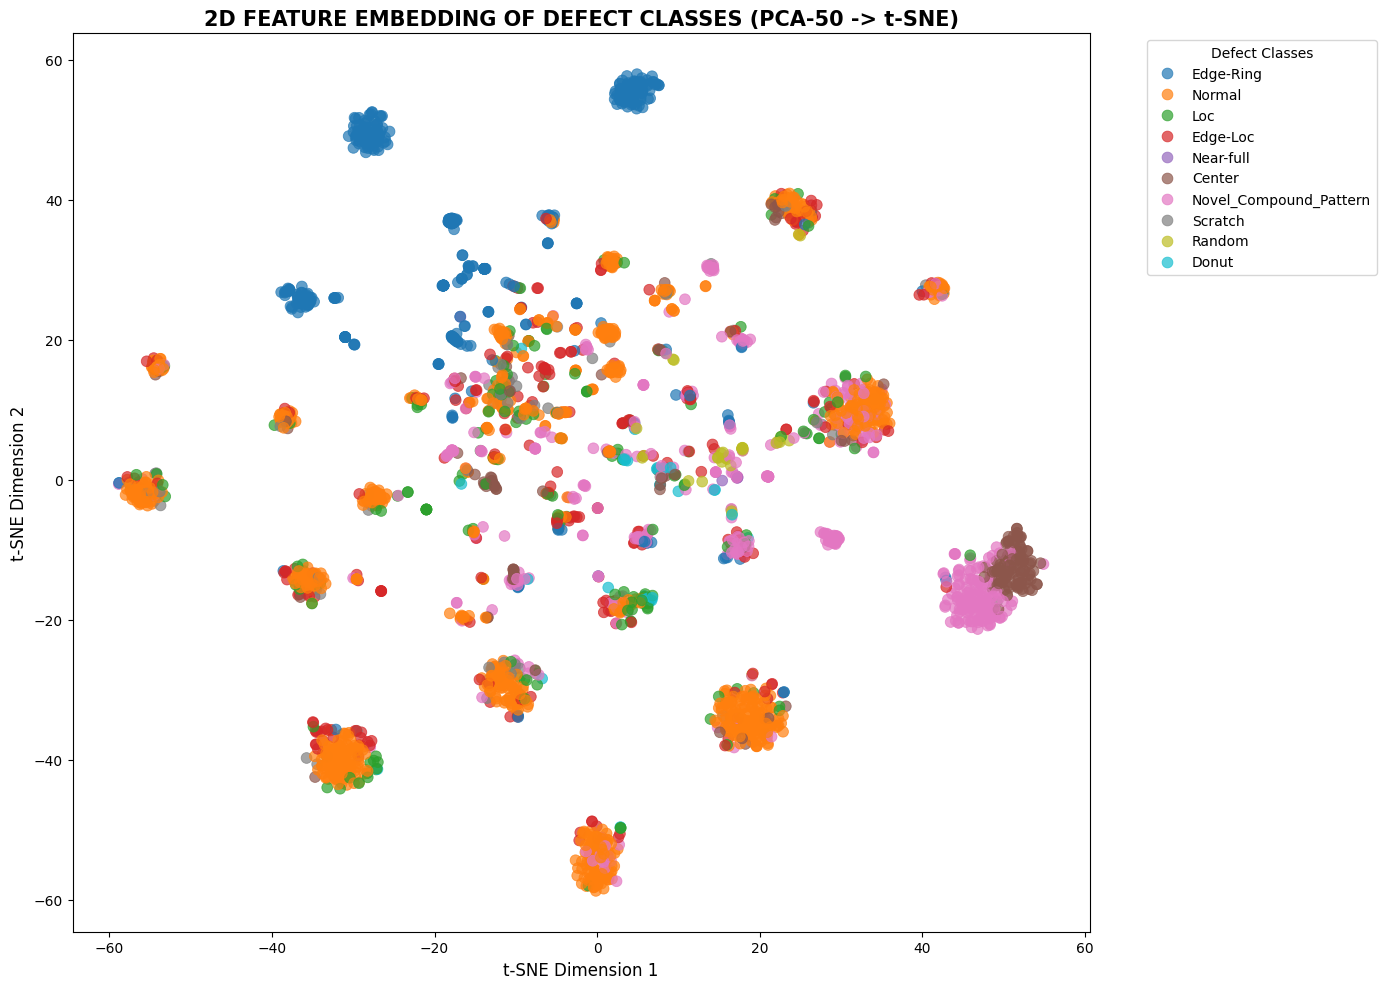

In [29]:
print("Projecting defect classes to 2D feature space via PCA-50 -> t-SNE...")

sample_viz = df_train_version2.sample(n=min(3000, len(df_train_version2)), random_state=42)
X_viz_flat = np.array([wm.flatten() for wm in sample_viz['waferMap_resized'].values])
y_viz = sample_viz['failureType'].values

# 1. PCA pre-reduction from 4096 dimensions to 50 dimensions to avoid Curse of Dimensionality
pca_pre_tsne = PCA(n_components=50, random_state=42)
X_viz_pca = pca_pre_tsne.fit_transform(X_viz_flat)

# 2. t-SNE manifold learning on 50D space (backward/forward compatible parameter handling)
try:
    tsne = TSNE(n_components=2, random_state=42, perplexity=35, max_iter=1000)
    features_2d = tsne.fit_transform(X_viz_pca)
except TypeError:
    tsne = TSNE(n_components=2, random_state=42, perplexity=35, n_iter=1000)
    features_2d = tsne.fit_transform(X_viz_pca)

# 3. 2D Scatter visualization
plt.figure(figsize=(14, 10))
sns.scatterplot(
    x=features_2d[:, 0], y=features_2d[:, 1],
    hue=y_viz,
    palette='tab10',
    s=60, alpha=0.7, edgecolor=None
)

plt.title('2D FEATURE EMBEDDING OF DEFECT CLASSES (PCA-50 -> t-SNE)', fontsize=15, fontweight='bold')
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Defect Classes")
plt.tight_layout()
plt.show()
